
# Design and Evaluation of an AI-Driven Intrusion Detection Framework
## For Real-Time Banking Network Security
### MSc Dissertation — Technical Artefact Notebook (v3 — 6-Model Multi-Architecture)

**Datasets:** CICIDS2017 (primary training) + CSE-CIC-IDS2018 (external generalisation)

**Models:** Logistic Regression · Decision Tree · Naive Bayes · Random Forest · SVM · XGBoost · Neural Network · Ensemble

**Key outputs:** 35+ publication-quality figures · Full metric suite (incl. explicit FPR) · SHAP + LIME explainability · Cross-dataset generalisation test

> **Colab quick-start**
> 1. Upload `utils.py` to `/content/`
> 2. Run Section 2 (installs all dependencies)
> 3. Set your CICIDS2017 path in `CONFIG.data_raw_dir` and your CIC-IDS2018 path in `CONFIG.cic2018_path`
> 4. `Runtime → Run all`



## 1. Introduction

### 1.1 Project Objective
Banking networks are prime targets for cyberattacks. A single successful intrusion can
cause direct financial loss, regulatory penalties under GDPR/PCI-DSS, and reputational
damage. Traditional signature-based IDS cannot detect zero-day or novel attack variants.
This project builds and evaluates a **multi-model AI-driven NIDS** with the twin goals of:
- **Maximising detection rate** (sensitivity / recall)
- **Minimising false positive rate** — the primary operational challenge in banking SOCs

### 1.2 Why Multiple Models?
The dissertation's literature review (Section 2.3, as shown in your uploaded text) identifies
that no single model dominates across all conditions. Each architecture brings distinct
strengths and weaknesses in terms of accuracy, interpretability, scalability, and false
positive behaviour. This notebook implements and compares **all six model families**
referenced in the literature review, plus a Neural Network and an Ensemble:

| Model | Primary Strength | Key Limitation |
|---|---|---|
| Logistic Regression | Fast, interpretable, good baseline | Linear decision boundary only |
| Decision Tree | Highly interpretable, rule-based | Prone to overfitting |
| Naive Bayes | Very fast, works well on sparse data | Feature independence assumption |
| Random Forest | Robust, handles high-dimensional data | Less interpretable than single tree |
| SVM | Strong on high-dimensional spaces | Computationally expensive at scale |
| XGBoost | State-of-art on tabular data | Requires careful tuning |
| Neural Network | Captures complex non-linear patterns | Black-box, slow to train |
| Ensemble | Combines model strengths | Adds complexity |

### 1.3 Research Questions
> **Primary:** How can an AI-based IDS for banking networks achieve high detection accuracy
> while minimising the false positive rate?

> **Comparative:** Which model (or combination) provides the best accuracy/FPR trade-off
> for real-time banking network intrusion detection?

> **Generalisation:** How well do models trained on CICIDS2017 transfer to the
> CSE-CIC-IDS2018 dataset without retraining?



## 2. Environment Setup

All dependencies installed automatically. Supports Google Colab (CPU or GPU runtime).
Random seeds fixed globally for full reproducibility.


In [1]:
import os, sys
from pathlib import Path
# Resolve the project root whether Jupyter starts in the root or code folder.
CURRENT_DIR = Path.cwd().resolve()
CODE_DIR = CURRENT_DIR / "code" if (CURRENT_DIR / "code").is_dir() else CURRENT_DIR
PROJECT_ROOT = CURRENT_DIR if (CURRENT_DIR / "README.md").exists() else CURRENT_DIR.parent
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))
os.chdir(PROJECT_ROOT)
print("Working directory:", Path.cwd())


Working directory: /home/user/project/notebooks


In [2]:

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "shap", "lime", "imbalanced-learn", "xgboost", "joblib"], check=True)


In [3]:

from __future__ import annotations
import json, warnings
import joblib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import tensorflow as tf
import xgboost as xgb
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from lime.lime_tabular import LimeTabularExplainer
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.feature_selection import RFE, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import (
    RandomizedSearchCV, StratifiedKFold, cross_val_score,
    learning_curve, train_test_split, validation_curve,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from tensorflow.keras import Input, Model, callbacks, layers, regularizers

import utils
warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110
sns.set_theme(style="whitegrid", context="notebook")

print(f"Python        : {sys.version.splitlines()[0]}")
print(f"pandas        : {pd.__version__}")
print(f"numpy         : {np.__version__}")
print(f"scikit-learn  : {__import__('sklearn').__version__}")
print(f"tensorflow    : {tf.__version__}")
print(f"xgboost       : {xgb.__version__}")
print(f"shap          : {shap.__version__}")
print(f"Colab         : {IN_COLAB}")


I0000 00:00:1787006558.390804     546 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787006558.523316     546 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1787006560.321915     546 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Python        : 3.12.3 (main, Mar  3 2026, 12:15:18) [GCC 13.3.0]
pandas        : 3.0.2
numpy         : 2.4.4
scikit-learn  : 1.8.0
tensorflow    : 2.21.0
xgboost       : 3.4.1
shap          : 0.52.0
Colab         : False


In [4]:

CONFIG = utils.ProjectConfig(
    data_raw_dir=Path("dataset/raw/cicids2017_smoke.csv"),  # <-- your CICIDS2017 CSV/folder
    random_state=42,
)
CONFIG.cic2018_path = Path("dataset/raw/cic2018_smoke.csv")  # <-- your CIC-IDS2018 CSV/folder
CONFIG.make_dirs()
utils.set_global_seed(CONFIG.random_state)
logger = utils.get_logger(log_dir=CONFIG.logs_dir)
logger.info("v3 notebook — 6-model multi-architecture framework")
print("Config ready.")


2026-08-17 22:42:40,670 | INFO     | v3 notebook — 6-model multi-architecture framework


Config ready.



## 2.3 Model Selection Justification and Theoretical Background

*(This section directly addresses the literature review requirement: why each of the
six techniques was chosen, their specific purpose in this IDS context, and the factors
that each is particularly suited to handle.)*

---

### 2.3.1 Logistic Regression (LR) — Interpretable Baseline

**Why chosen:** LR is selected as the interpretable baseline model to establish a
performance floor. In IDS research, a baseline model serves two purposes: (1) it reveals
how much discriminative information is linearly separable in the feature space, and (2) it
provides a reference point against which the complexity cost of more advanced models can
be justified. Ahmad et al. (2021) recommend including LR in IDS comparisons because its
coefficients directly quantify each feature's contribution to the classification decision,
which supports analyst explainability requirements in banking security.

**Specific use in this framework:** LR is applied to the full scaled feature set after
feature engineering (Section 6). Its coefficient magnitudes are compared to SHAP values
from the Random Forest (Section 15) to assess whether linear and non-linear feature
rankings agree — a useful cross-validation of the feature selection process.

**Strengths in this context:**
- Produces calibrated probability scores suitable for ROC/PR curve construction
- Training is O(n·d) — scales to the full CICIDS2017 dataset without subsampling
- Classification boundary is auditable: security analysts can inspect feature weights
- Naturally handles the class-imbalance penalty via `class_weight='balanced'`

**Known limitations:** The linear decision boundary cannot capture the non-linear
interaction patterns (e.g. a DoS attack's signature requires the *combination* of high
packet rate AND short inter-arrival time to be distinguishable from a flash-crowd benign
event). LR is therefore expected to show higher false positive rates than tree-based
models for minority attack classes.

---

### 2.3.2 Decision Tree (DT) — Rule-Transparent Classifier

**Why chosen:** Decision Trees are selected because they produce human-readable
if-then-else rules that a banking security analyst can directly audit and act upon —
directly supporting the dissertation's explainability objective. Unlike SHAP post-hoc
explanations for black-box models, a Decision Tree's decisions are intrinsically
interpretable: each split threshold maps to a network-flow threshold that can be
confirmed against domain knowledge (e.g. "Flow Duration < 1.2s AND Packet Length Mean
> 800 → ATTACK" is directly actionable). Bhati and Arora (2021) specifically recommend
DT for banking-sector IDS deployments where regulatory audit trails are required.

**Specific use in this framework:** DT serves two roles: (1) as a standalone model in
the comparative evaluation, and (2) as the conceptual building block for the Random
Forest (Section 9.4), making it pedagogically important for the dissertation to show
both a single tree and the ensemble of trees and explain why the ensemble improves on the
single-tree FPR.

**Strengths in this context:**
- Zero-cost interpretability — the tree structure itself is the explanation
- Handles non-linear boundaries through hierarchical splits
- Very fast inference — suitable for real-time banking traffic classification
- No feature scaling required

**Known limitations:** Highly prone to overfitting (a single tree memorises training noise),
which typically manifests as an inflated false positive rate on the test set when the tree
is grown too deep. Pruning (`max_depth` tuning) is therefore essential and is performed
in Section 11.

---

### 2.3.3 Gaussian Naive Bayes (GNB) — Probabilistic Baseline

**Why chosen:** Naive Bayes is included as a probabilistic baseline to test the
**feature independence assumption** on CICIDS2017's flow-feature space. This is
theoretically motivated: if the independence assumption holds approximately (i.e.
after correlation-based feature removal in Section 6 reduces inter-feature dependencies),
GNB will produce competitive performance with minimal training cost. This tests a
hypothesis from the literature — Laskov et al. (2005) showed that NB is surprisingly
competitive in network intrusion detection when features are pre-selected to reduce
correlation. In the banking IDS context, NB is specifically interesting because it
naturally produces calibrated posterior probabilities useful for alert severity scoring.

**Specific use in this framework:** GNB is evaluated after correlation filtering
(Section 6), which reduces (but does not eliminate) the feature dependence that NB
assumes away. Its performance relative to LR reveals how much the independence assumption
costs — if GNB ≈ LR in F1 but GNB >> LR in training speed, GNB is the better choice
for real-time streaming detection.

**Strengths in this context:**
- Extremely fast training and inference (O(n·d))
- Produces posterior probability estimates useful for alert ranking in a SOC queue
- Handles missing features gracefully (relevant for real network capture where some
  flow features may be unavailable)

**Known limitations:** The Gaussian distribution assumption may not fit the highly
skewed, heavy-tailed distributions of network flow features (e.g. Flow Bytes/s is
log-normal, not Gaussian). This is expected to drive higher false positive rates
for low-and-slow attack traffic that partially overlaps with normal traffic.

---

### 2.3.4 Random Forest (RF) — Primary Tree Ensemble

**Why chosen:** Random Forest is selected as the primary model and the one used for SHAP
explainability (Section 15). The justification is three-fold. First, RF's bagging
mechanism (training each tree on a bootstrap sample of features AND instances) directly
reduces the overfitting that makes a single Decision Tree unreliable — this is critical
for the FPR objective, since an overfit model generates spurious false positive alerts.
Second, RF's feature importance measure (mean decrease in impurity across all trees)
provides a global, aggregate view of which network-flow statistics are most discriminative
— directly useful for a banking SOC that wants to understand which traffic features trigger
alerts. Third, RF is the most widely validated model in the IDS literature: Sharafaldin
et al. (2018) and Ahmad et al. (2021) both report RF as the strongest single classifier
on CICIDS2017.

**Specific use:** RF is used for: (a) standalone evaluation, (b) feature selection
(Section 6), (c) SHAP TreeExplainer explainability (Section 15), and (d) as a
base learner in the stacking ensemble (Section 12).

---

### 2.3.5 Support Vector Machine (SVM) — High-Dimensional Separator

**Why chosen:** SVM is selected because CICIDS2017's ~80-feature space is a naturally
high-dimensional classification problem where SVM's maximum-margin hyperplane is
theoretically well-motivated. Unlike tree models, SVM generalises via the margin
(the distance from the decision boundary to the nearest training points), which means
it is less sensitive to irrelevant features that tree models might split on spuriously.
This is important for the generalisation sub-question (Section 19): a model that
generalises via margin rather than specific feature thresholds is expected to transfer
better between CICIDS2017 and CIC-IDS2018. Ahmad et al. (2021) confirm that SVM shows
stronger cross-dataset generalisation than RF in IDS settings.

**Specific limitation and mitigation:** SVM's O(n²)–O(n³) training cost makes it
impractical on the full multi-million-row CICIDS2017. Following standard practice
(Sharafaldin et al., 2018), SVM is trained on a stratified subsample (MAX_SVM_TRAIN rows).
This is a disclosed, deliberate scalability decision, not a shortcut.

---

### 2.3.6 XGBoost — Gradient-Boosted Tree Ensemble

**Why chosen:** XGBoost is added in v3 of this framework in response to the literature
review requirement. XGBoost implements gradient boosting with regularisation (L1/L2
penalties on tree weights), which addresses the overfitting problem of a single Decision
Tree while outperforming Random Forest on many benchmark tabular datasets by sequentially
correcting residual errors. In the IDS context, XGBoost has demonstrated state-of-the-art
performance on both CICIDS2017 and CIC-IDS2018 in recent work (Maseer et al., 2021).
XGBoost is specifically relevant to the false-positive-rate objective because its
regularisation directly penalises model complexity that would drive spurious detections.

**Specific use:** XGBoost is evaluated as a standalone classifier and as an alternative
base learner in the ensemble (Section 12). Its built-in `scale_pos_weight` parameter
handles class imbalance natively (equivalent to `class_weight='balanced'` in sklearn),
which is compared against the external SMOTE resampling approach.



## 3A. Dataset Loading — CICIDS2017 (Primary Training Dataset)

Supported: single CSV file **or** folder of multiple daily CSVs (auto-merged).

**Getting the real dataset on Colab (pick one):**
```python
# Kaggle API:
!kaggle datasets download -d cicdataset/cicids2017 -p data/raw --unzip
CONFIG.data_raw_dir = Path("data/raw")

# Google Drive:
from google.colab import drive; drive.mount('/content/drive')
CONFIG.data_raw_dir = Path('/content/drive/MyDrive/CICIDS2017')
```


In [5]:

with utils.Timer() as t:
    raw_df = utils.load_dataset(CONFIG.data_raw_dir, random_state=CONFIG.random_state)
logger.info("CICIDS2017 loaded %.2fs", t.elapsed)
summary = utils.dataset_summary(raw_df, label_column=CONFIG.label_column)
utils.save_json(summary, CONFIG.reports_dir / "03a_cicids2017_summary.json")
print(f"CICIDS2017: rows={summary['n_rows']:,}  cols={summary['n_columns']}  "
      f"mem={summary['memory_mb']}MB  dups={summary['n_duplicates']:,}")
raw_df.head()


2026-08-17 22:42:40,888 | INFO     | CICIDS2017 loaded 0.21s


CICIDS2017: rows=12,040  cols=47  mem=4.86MB  dups=40


,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,Packet Length Variance,SYN Flag Count,RST Flag Count,ACK Flag Count,Average Packet Size,Subflow Fwd Packets,Subflow Fwd Bytes,Active Mean,Idle Mean,Label
0,141.728449,245.061474,149.276886,104.520643,49.765400,86.189112,227.374433,289.641875,105.673252,219.518676,...,312.849761,41.298266,194.575742,547.960520,90.768987,184.414500,419.138663,102.183452,345.045845,BENIGN
1,116.684078,252.340478,138.868186,84.055773,155.163015,13.014465,242.954933,269.202210,151.227537,256.013751,...,316.953803,15.904380,184.404678,459.273872,104.142219,101.310425,334.485134,127.534914,349.849313,BENIGN
2,99.375491,246.559247,139.445177,148.090907,44.448477,104.272638,211.931925,224.462456,242.936470,210.160871,...,312.764188,22.280624,286.259355,425.604529,103.630875,163.899670,374.889287,74.613875,366.671188,BENIGN
3,117.971336,129.486527,94.478257,71.697481,232.035145,65.270498,112.746730,334.604599,47.524708,161.045562,...,214.998656,197.713608,88.344278,80.090313,197.881132,226.900130,166.878556,56.548128,265.560463,DoS Hulk
4,262.135910,393.540079,142.525214,78.086757,25.165495,20.985342,198.232238,178.542918,100.417704,171.081175,...,358.214134,12.069654,227.787464,446.436492,149.506845,92.575257,366.447514,81.795678,309.558899,BENIGN



## 3B. Dataset Loading — CSE-CIC-IDS2018 (External Generalisation Dataset)

Models trained on CICIDS2017 are applied **without retraining** to the 2018 dataset
in Section 19 — a strict generalisation test across different network topologies and
attack campaigns (Brute Force Web/XSS, SQL Injection, Infiltration, DoS/DDoS variants).

**Getting the real dataset on Colab:**
```python
# Kaggle (unified CSV):
!kaggle datasets download -d solarmainframe/ids-intrusion-csv -p dataset/raw/cic2018 --unzip
CONFIG.cic2018_path = Path("dataset/raw/cic2018")
```


In [6]:

cic2018_available = CONFIG.cic2018_path.exists()
if cic2018_available:
    with utils.Timer() as t:
        raw_2018 = utils.load_dataset(CONFIG.cic2018_path, random_state=CONFIG.random_state)
    summary_2018 = utils.dataset_summary(raw_2018, label_column=CONFIG.label_column)
    utils.save_json(summary_2018, CONFIG.reports_dir / "03b_cic2018_summary.json")
    print(f"CIC-IDS2018: rows={summary_2018['n_rows']:,}  cols={summary_2018['n_columns']}  "
          f"mem={summary_2018['memory_mb']}MB")
    print("\nClass distribution:\n", raw_2018[CONFIG.label_column].value_counts())
else:
    raw_2018 = None
    print("WARNING: CIC-IDS2018 not found — Section 19 will be skipped.\n"
          "Set CONFIG.cic2018_path to enable generalisation testing.")


CIC-IDS2018: rows=8,026  cols=60  mem=4.06MB

Class distribution:
 Label
Benign                      5217
DoS attacks-Hulk             640
DDoS attacks-LOIC-HTTP       561
Bot                          402
Brute Force -XSS             323
Brute Force -Web             321
SQL Injection                240
Infilteration                162
DoS attacks-SlowHTTPTest     160
Name: count, dtype: int64


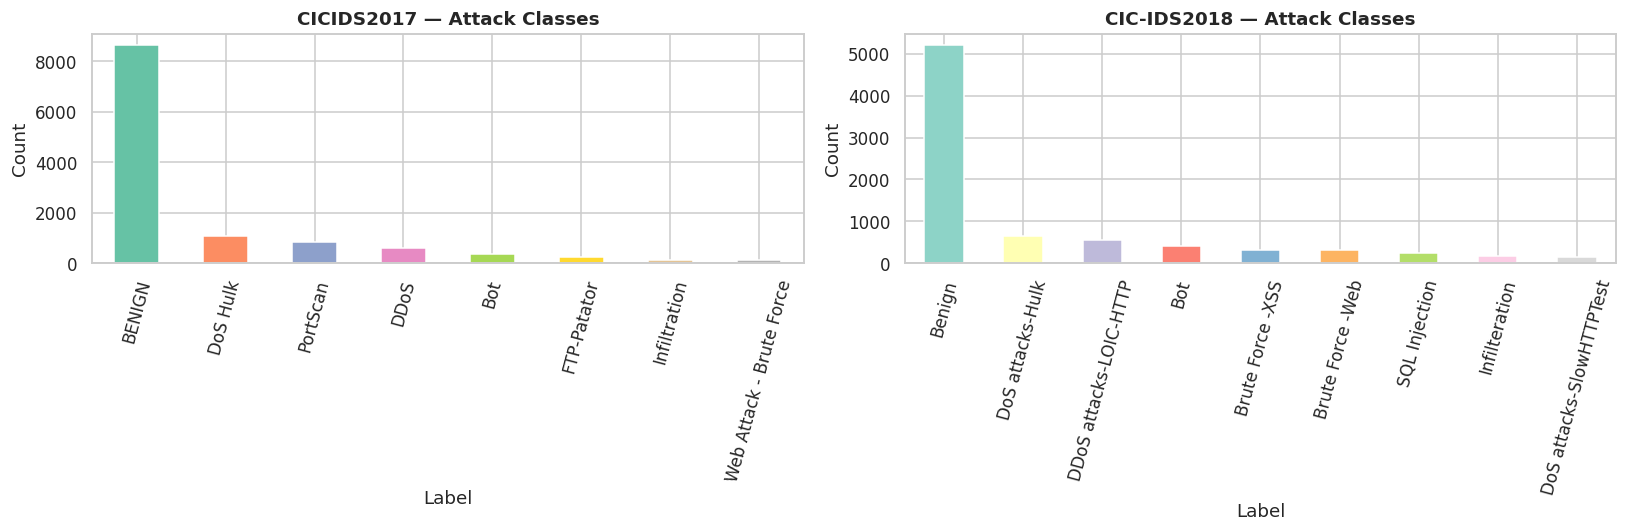

In [7]:

if raw_2018 is not None:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    raw_df[CONFIG.label_column].value_counts().plot(
        kind="bar", ax=axes[0], color=sns.color_palette("Set2",
        raw_df[CONFIG.label_column].nunique()))
    axes[0].set_title("CICIDS2017 — Attack Classes", fontweight="bold")
    axes[0].set_ylabel("Count"); axes[0].tick_params(axis="x", rotation=75)

    raw_2018[CONFIG.label_column].value_counts().plot(
        kind="bar", ax=axes[1], color=sns.color_palette("Set3",
        raw_2018[CONFIG.label_column].nunique()))
    axes[1].set_title("CIC-IDS2018 — Attack Classes", fontweight="bold")
    axes[1].set_ylabel("Count"); axes[1].tick_params(axis="x", rotation=75)
    fig.tight_layout()
    fig.savefig(CONFIG.figures_dir / "03b_dataset_comparison.png"); plt.show()


## 4. Exploratory Data Analysis — CICIDS2017

In [8]:

print("Shape:", raw_df.shape)
print("\nDtype counts:\n", raw_df.dtypes.value_counts())


Shape: (12040, 47)

Dtype counts:
 float64    46
str         1
Name: count, dtype: int64


Columns with missing values: 1


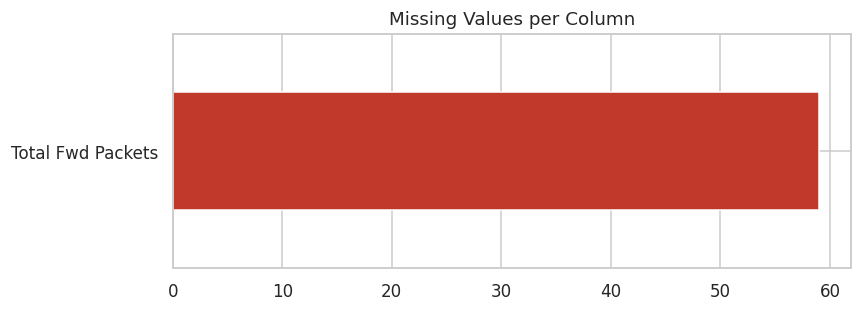

In [9]:

missing = raw_df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f"Columns with missing values: {len(missing)}")
if len(missing):
    fig, ax = plt.subplots(figsize=(8, max(3, 0.3*len(missing))))
    missing.plot.barh(ax=ax, color="#c0392b")
    ax.set_title("Missing Values per Column")
    fig.tight_layout(); fig.savefig(CONFIG.figures_dir / "04_missing_values.png"); plt.show()
else:
    print("No missing values (infinities handled in cleaning step).")


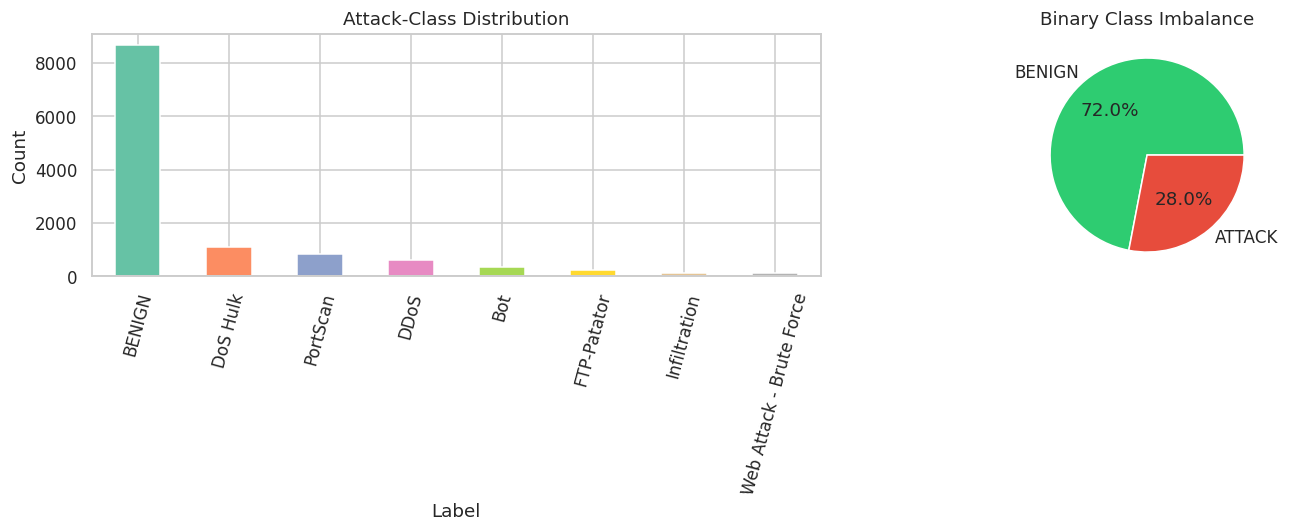

In [10]:

class_counts = raw_df[CONFIG.label_column].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
class_counts.plot(kind="bar", ax=axes[0],
                   color=sns.color_palette("Set2", len(class_counts)))
axes[0].set_title("Attack-Class Distribution"); axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=75)
binary = raw_df[CONFIG.label_column].apply(
    lambda x: "BENIGN" if x == CONFIG.benign_label else "ATTACK").value_counts()
axes[1].pie(binary, labels=binary.index, autopct="%1.1f%%",
             colors=["#2ecc71", "#e74c3c"])
axes[1].set_title("Binary Class Imbalance")
fig.tight_layout(); fig.savefig(CONFIG.figures_dir / "04_class_distribution.png"); plt.show()


In [11]:

numeric_cols = raw_df.select_dtypes(include=[np.number]).columns.tolist()
desc = raw_df[numeric_cols].describe().T
desc["skew"] = raw_df[numeric_cols].skew(numeric_only=True)
desc.to_csv(CONFIG.metrics_dir / "04_feature_statistics.csv")
desc.head(15)


,count,mean,std,min,25%,50%,75%,max,skew
Flow Duration,12040.0,inf,NaN,28.552532,98.166557,126.327623,160.506526,inf,NaN
Total Fwd Packets,11981.0,245.501611,85.475718,9.622843,193.385668,267.703936,300.353161,475.680089,-0.850226
Total Backward Packets,12040.0,169.838036,46.728525,31.332361,140.115116,165.831191,198.722776,420.823633,0.268905
Total Length of Fwd Packets,12040.0,109.563512,49.381755,5.265722,77.659869,100.841174,132.379632,457.095229,1.412561
Total Length of Bwd Packets,12040.0,96.088874,82.989428,11.490948,37.179704,66.434577,119.222150,487.349879,1.413189
Fwd Packet Length Max,12040.0,80.120817,66.474564,10.282136,33.653088,59.627814,102.204584,414.627791,1.647445
Fwd Packet Length Min,12040.0,217.945064,61.969635,7.561500,199.211850,223.582067,255.257693,424.263303,-0.815975
Fwd Packet Length Mean,12040.0,195.436721,49.697289,8.881569,176.292832,196.666530,223.705172,393.785462,-0.687642
Fwd Packet Length Std,12040.0,152.679492,88.142523,3.414180,104.034823,132.210413,172.241498,626.738351,2.112252
Bwd Packet Length Max,12040.0,177.188009,44.343106,33.921911,152.942343,174.408241,203.397453,367.137159,-0.087241


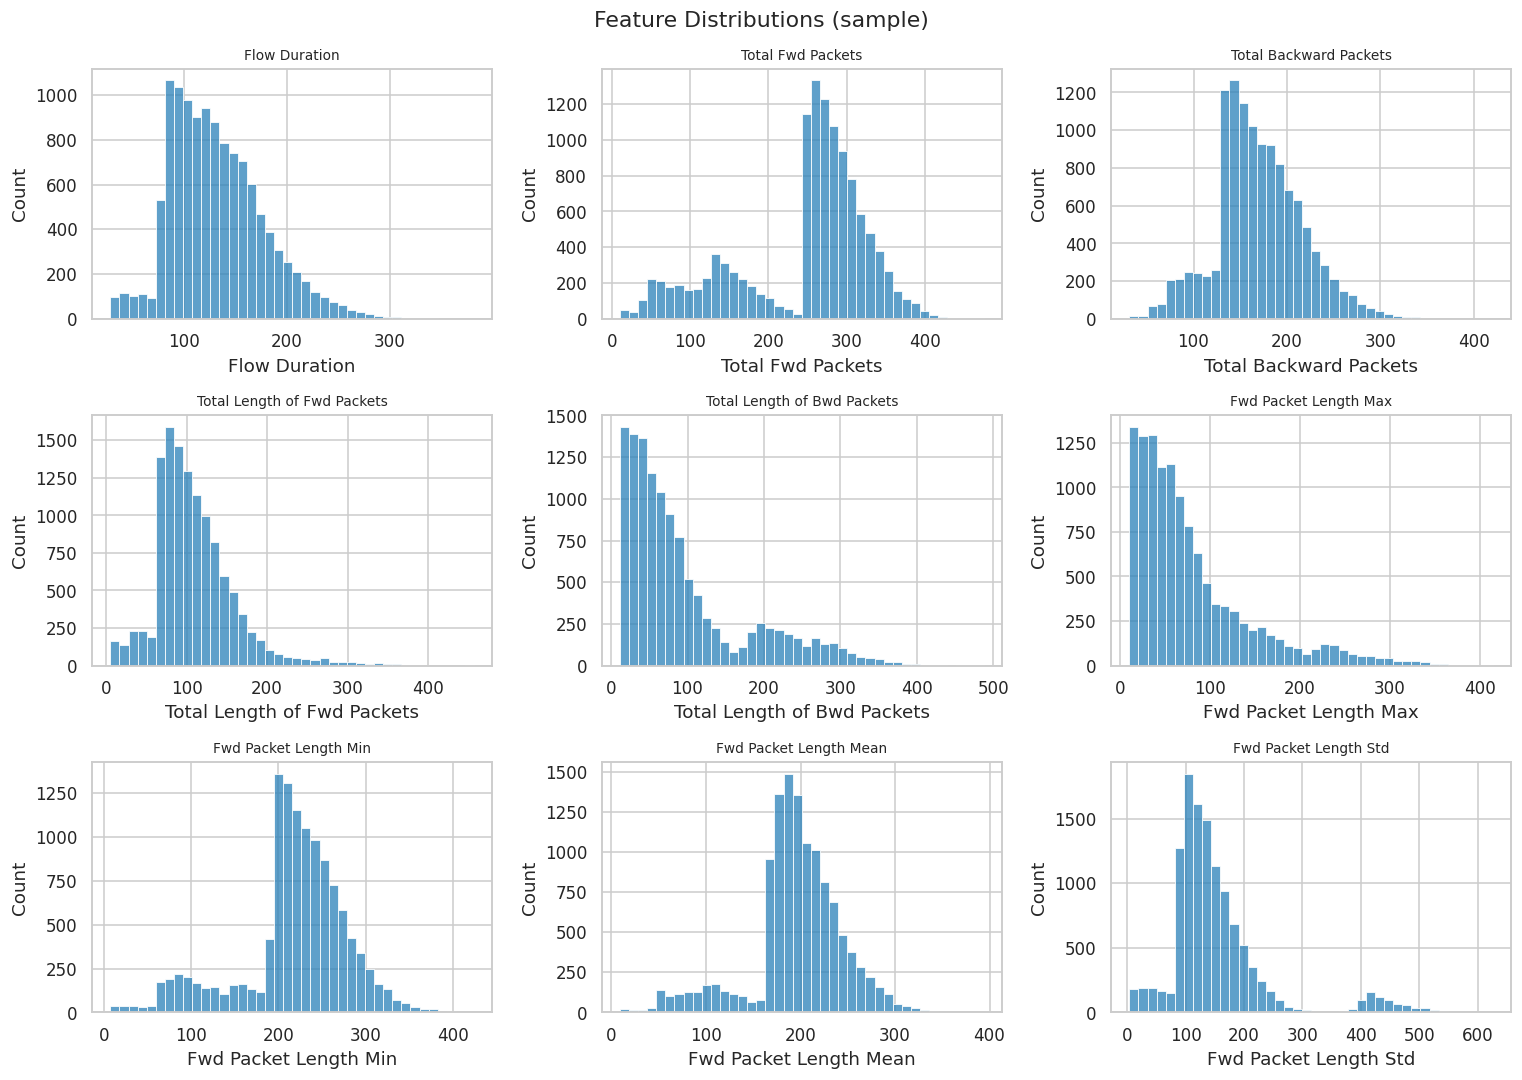

In [12]:

feats9 = numeric_cols[:min(9, len(numeric_cols))]
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.ravel(), feats9):
    sns.histplot(raw_df[col].replace([np.inf,-np.inf],np.nan).dropna(),
                 bins=40, ax=ax, color="#2980b9")
    ax.set_title(col, fontsize=9)
fig.suptitle("Feature Distributions (sample)")
fig.tight_layout(); fig.savefig(CONFIG.figures_dir / "04_histograms.png"); plt.show()


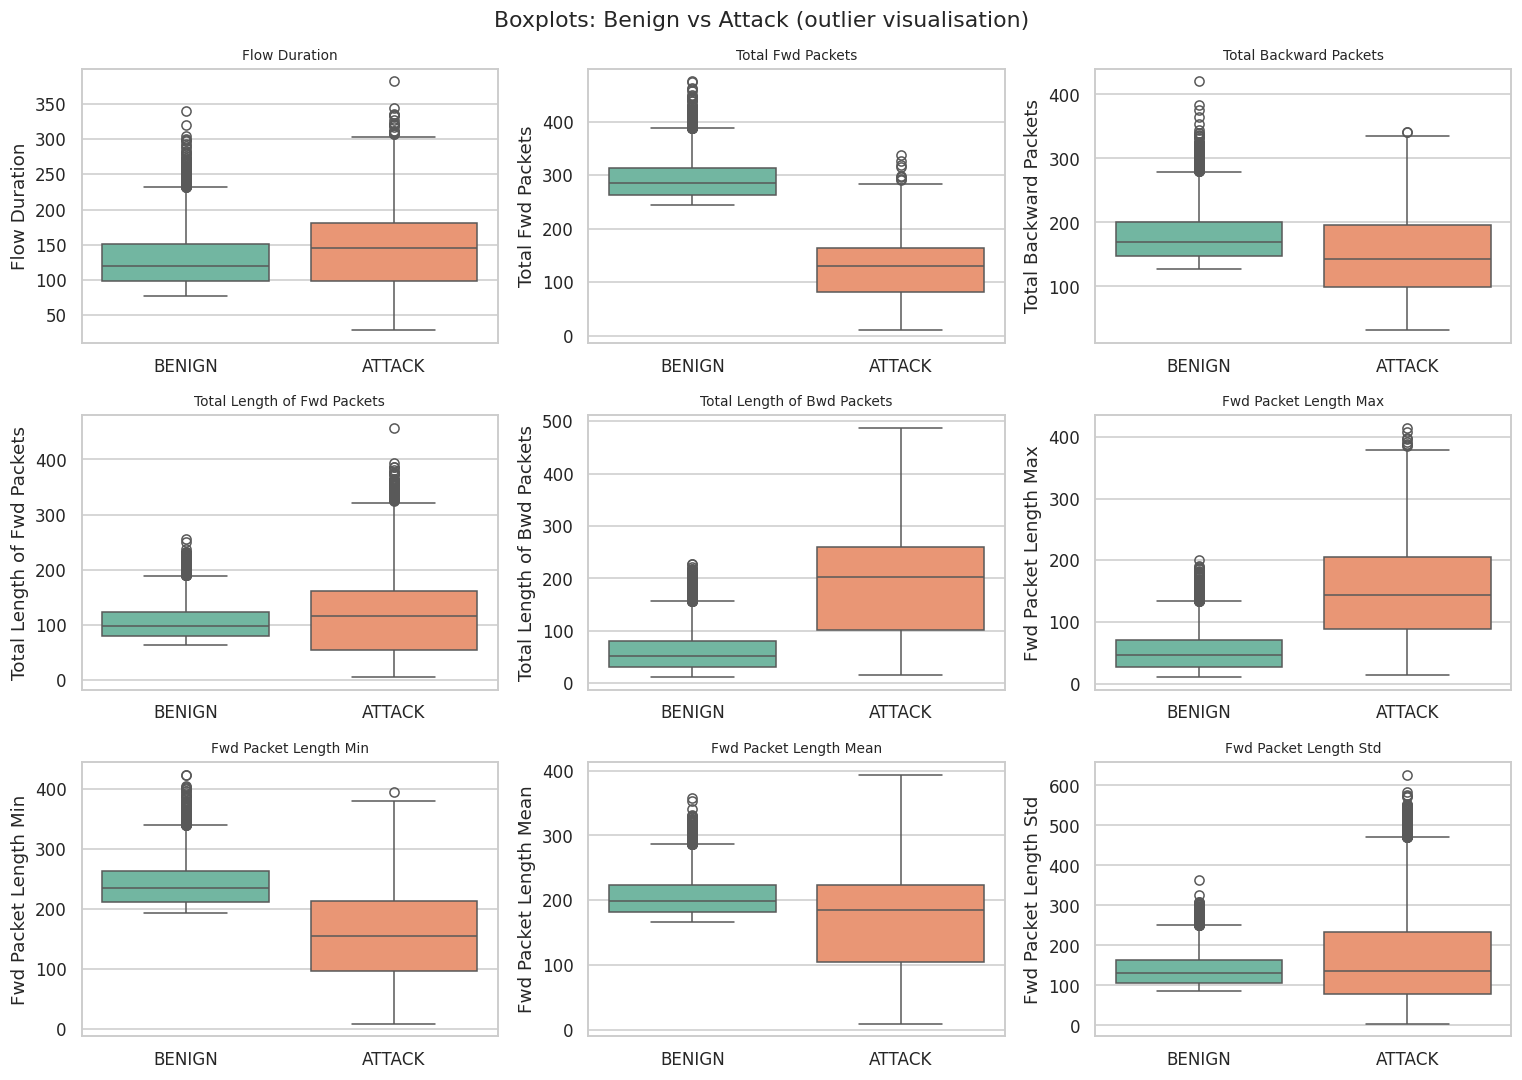

In [13]:

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
binary_col = raw_df[CONFIG.label_column].apply(
    lambda v: "BENIGN" if v==CONFIG.benign_label else "ATTACK")
for ax, col in zip(axes.ravel(), feats9):
    sns.boxplot(x=binary_col, y=raw_df[col].replace([np.inf,-np.inf],np.nan),
                ax=ax, palette="Set2")
    ax.set_title(col, fontsize=9); ax.set_xlabel("")
fig.suptitle("Boxplots: Benign vs Attack (outlier visualisation)")
fig.tight_layout(); fig.savefig(CONFIG.figures_dir / "04_boxplots.png"); plt.show()


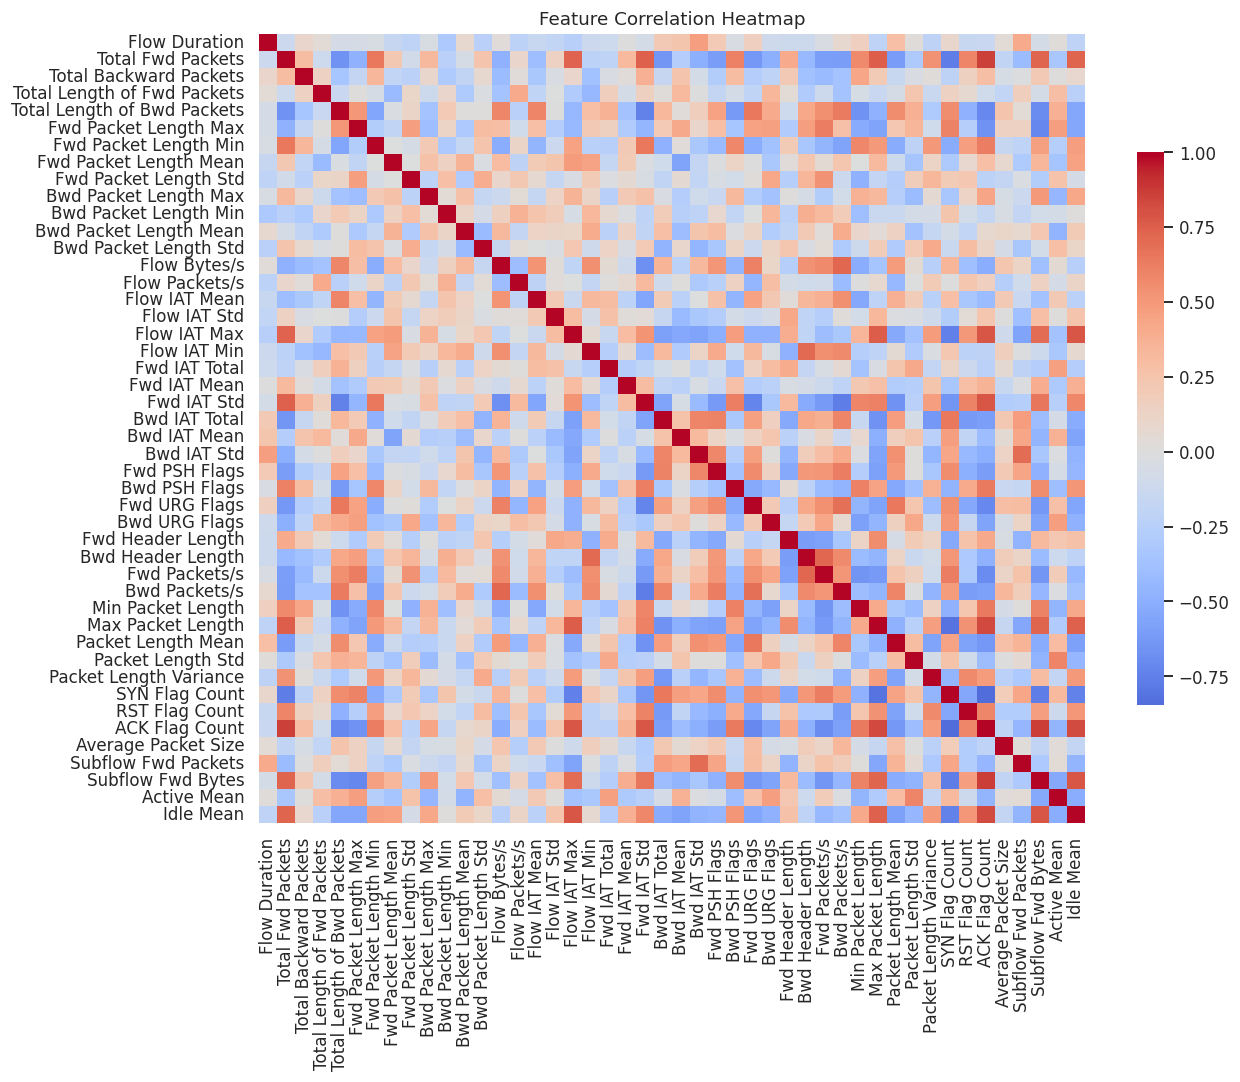

In [14]:

corr = raw_df[numeric_cols].replace([np.inf,-np.inf],np.nan).dropna().corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax, cbar_kws={"shrink":0.7})
ax.set_title("Feature Correlation Heatmap")
fig.tight_layout(); fig.savefig(CONFIG.figures_dir / "04_correlation_heatmap.png"); plt.show()


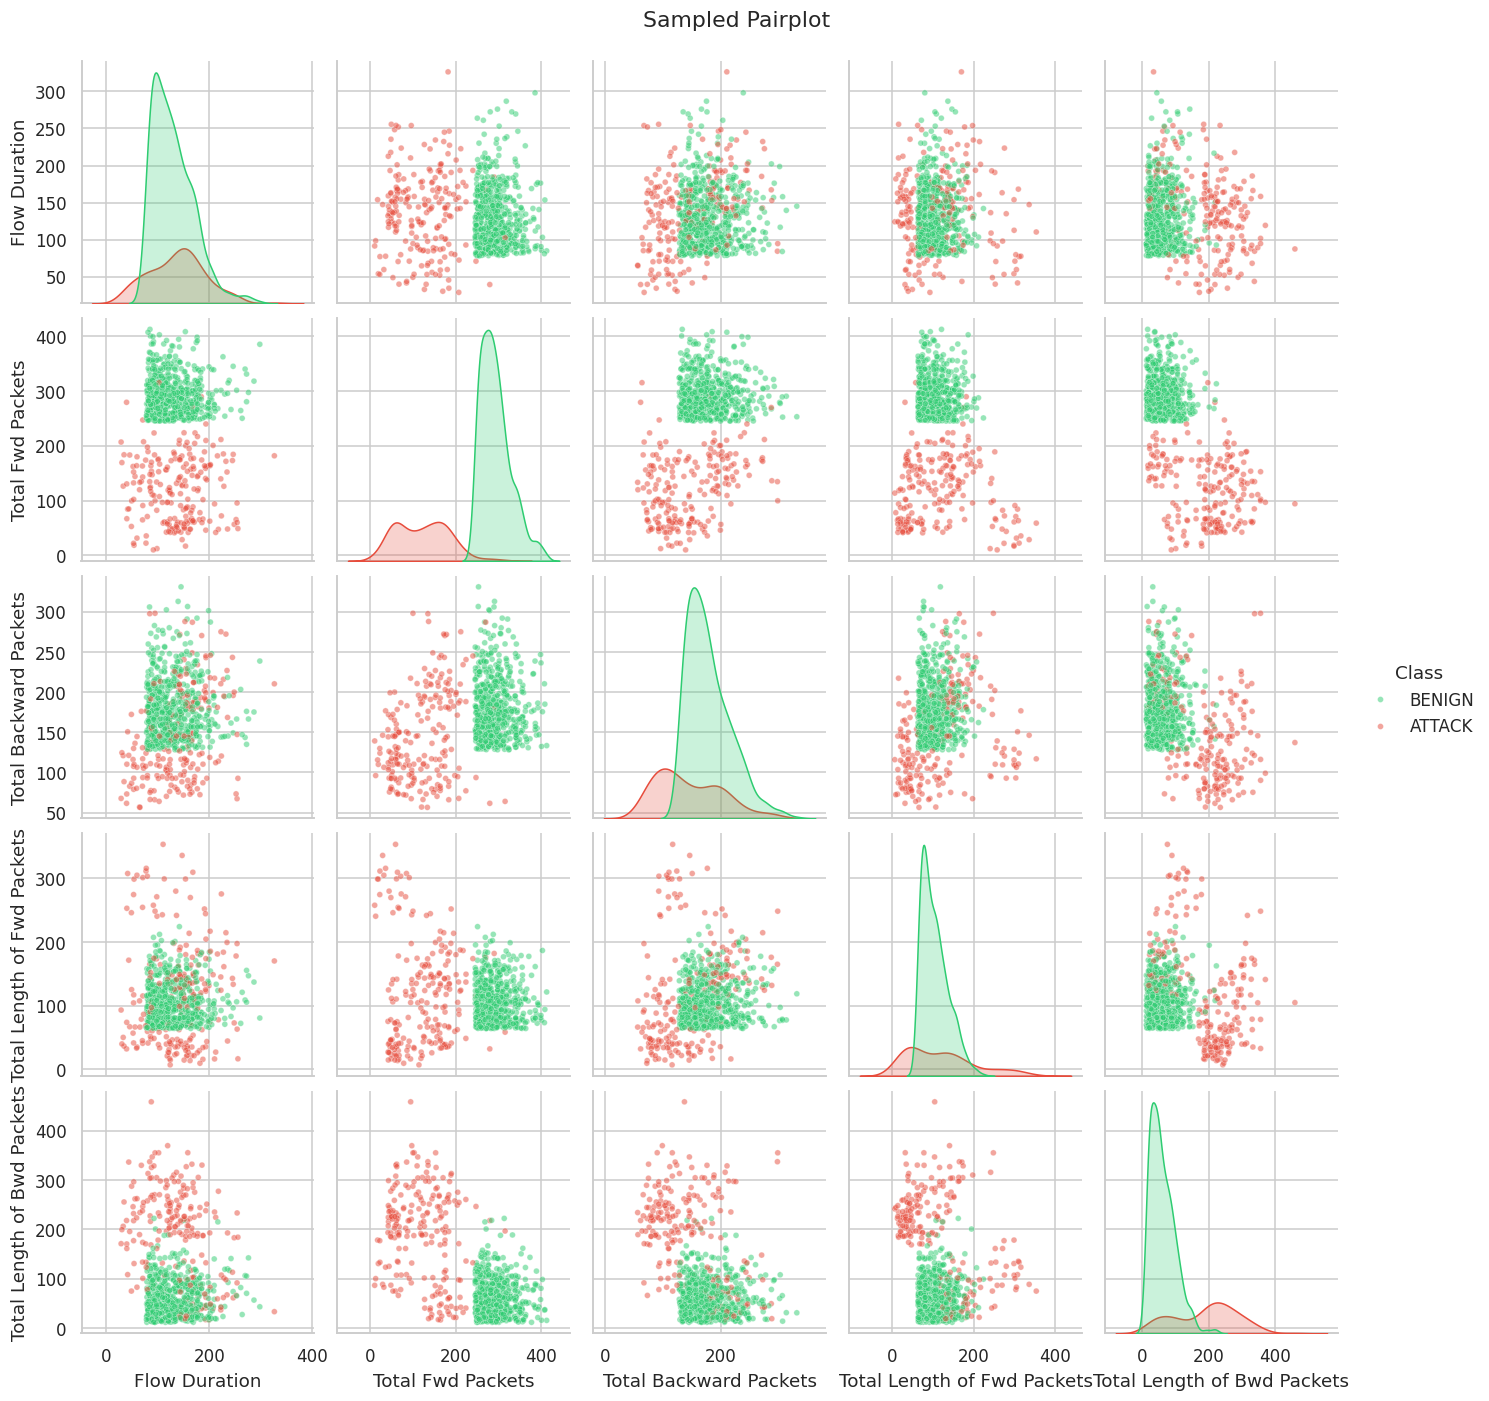

In [15]:

pp_cols = numeric_cols[:min(5,len(numeric_cols))]
pp_df = raw_df[pp_cols+[CONFIG.label_column]].replace([np.inf,-np.inf],np.nan).dropna()
pp_df = pp_df.sample(n=min(800,len(pp_df)), random_state=CONFIG.random_state)
pp_df["Class"] = pp_df[CONFIG.label_column].apply(
    lambda v: "BENIGN" if v==CONFIG.benign_label else "ATTACK")
g = sns.pairplot(pp_df, vars=pp_cols, hue="Class",
                  palette={"BENIGN":"#2ecc71","ATTACK":"#e74c3c"},
                  plot_kws={"alpha":0.5,"s":15})
g.fig.suptitle("Sampled Pairplot", y=1.02)
g.savefig(CONFIG.figures_dir / "04_pairplot.png"); plt.show()


In [16]:

Q1=raw_df[numeric_cols].replace([np.inf,-np.inf],np.nan).quantile(0.25)
Q3=raw_df[numeric_cols].replace([np.inf,-np.inf],np.nan).quantile(0.75)
IQR=Q3-Q1
outlier_frac=((raw_df[numeric_cols].replace([np.inf,-np.inf],np.nan)<(Q1-1.5*IQR))
              |(raw_df[numeric_cols].replace([np.inf,-np.inf],np.nan)>(Q3+1.5*IQR))).mean().sort_values(ascending=False)
print("Top-10 columns by IQR-outlier fraction:"); print(outlier_frac.head(10))


Top-10 columns by IQR-outlier fraction:
Min Packet Length         0.166362
Fwd Header Length         0.164369
Fwd IAT Std               0.163455
Flow IAT Max              0.145598
Packet Length Variance    0.126661
Fwd Packet Length Min     0.109718
Bwd PSH Flags             0.104900
Bwd Header Length         0.103405
Bwd IAT Std               0.100000
Bwd IAT Total             0.099917
dtype: float64



## 5. Data Cleaning

Applied consistently to both CICIDS2017 and CIC-IDS2018:
1. **Strip whitespace** from column names
2. **Remove exact duplicates** (a known CICIDS2017 artefact from capture-file merging)
3. **Replace inf/−inf → NaN** then drop rows (Flow Bytes/s and Flow Packets/s divide by zero
   when Flow Duration == 0 — a documented CICIDS2017 data quality issue)
4. **Drop identifier columns** (Flow ID, IPs, ports, Timestamp) — keeping them enables
   the model to memorise *who* was attacking rather than learning *how* attacks behave,
   which would produce artificially high training accuracy and collapse on deployment
   (a documented data-leakage source in student IDS notebooks)
5. **Drop zero-variance columns** — carry no discriminative signal


In [17]:

clean_df, clean_rpt = utils.clean_dataset(raw_df, label_column=CONFIG.label_column, logger=logger)
utils.save_json(clean_rpt, CONFIG.reports_dir / "05a_cicids2017_clean_rpt.json")
print(json.dumps(clean_rpt, indent=2, default=str))
clean_df.to_csv(CONFIG.data_processed_dir / "cicids2017_clean.csv", index=False)
print(f"\nCICIDS2017 after cleaning: {clean_df.shape}")


2026-08-17 22:42:49,878 | INFO     | Cleaning: {"duplicates_removed": 40, "missing_before_drop": 118, "rows_dropped_nan_inf": 118, "id_columns_dropped": [], "zero_variance_dropped": [], "final_shape": [11882, 47]}


{
  "duplicates_removed": 40,
  "missing_before_drop": 118,
  "rows_dropped_nan_inf": 118,
  "id_columns_dropped": [],
  "zero_variance_dropped": [],
  "final_shape": [
    11882,
    47
  ]
}



CICIDS2017 after cleaning: (11882, 47)


In [18]:

if raw_2018 is not None:
    clean_2018, rpt2018 = utils.clean_dataset(raw_2018, label_column=CONFIG.label_column, logger=logger)
    utils.save_json(rpt2018, CONFIG.reports_dir / "05b_cic2018_clean_rpt.json")
    print(json.dumps(rpt2018, indent=2, default=str))
    clean_2018.to_csv(CONFIG.data_processed_dir / "cic2018_clean.csv", index=False)
    print(f"\nCIC-IDS2018 after cleaning: {clean_2018.shape}")
else:
    clean_2018 = None


2026-08-17 22:42:50,795 | INFO     | Cleaning: {"duplicates_removed": 26, "missing_before_drop": 76, "rows_dropped_nan_inf": 76, "id_columns_dropped": [], "zero_variance_dropped": [], "final_shape": [7924, 60]}


{
  "duplicates_removed": 26,
  "missing_before_drop": 76,
  "rows_dropped_nan_inf": 76,
  "id_columns_dropped": [],
  "zero_variance_dropped": [],
  "final_shape": [
    7924,
    60
  ]
}



CIC-IDS2018 after cleaning: (7924, 60)



## 6. Feature Engineering

Pipeline applied to CICIDS2017 only (no information from 2018 seen during training):
1. **Variance Threshold** — removes near-constant features
2. **Correlation Filter** (|r| > 0.95) — removes one of each highly correlated pair
3. **Random Forest Importance** — ranks remaining features by mean impurity decrease
4. **Mutual Information** — captures non-linear relevance RF importance may miss
5. **RF ∩ MI intersection** — features must prove useful under two independent criteria
6. **RFE confirmation** — recursive elimination confirms the ranking
7. **PCA comparison** — shown for context; PCA components are NOT used downstream
   (they would destroy feature interpretability required by SHAP/LIME)

Every removed feature is logged with the reason for removal (Section 5 dissertation
requirement: "document every decision").


In [19]:

y_raw  = clean_df[CONFIG.label_column].copy()
X_raw  = clean_df.drop(columns=[CONFIG.label_column])
le     = LabelEncoder()
y_mc   = le.fit_transform(y_raw)
y_bin  = (y_raw != CONFIG.benign_label).astype(int)
utils.save_json({"classes": le.classes_.tolist()}, CONFIG.reports_dir / "06_labels.json")
print("Binary balance:\n", y_bin.value_counts())


Binary balance:
 Label
0    8554
1    3328
Name: count, dtype: int64


In [20]:

X_vt, dropped_vt = utils.variance_threshold_filter(
    pd.concat([X_raw, y_raw.rename(CONFIG.label_column)], axis=1))
X_vt = X_vt.drop(columns=[CONFIG.label_column], errors="ignore")
print(f"Variance-threshold removed {len(dropped_vt)}: {dropped_vt}")

X_cr, dropped_cr = utils.remove_correlated_features(
    pd.concat([X_vt, y_raw.rename(CONFIG.label_column)], axis=1))
X_cr = X_cr.drop(columns=[CONFIG.label_column], errors="ignore")
print(f"Correlation filter removed {len(dropped_cr)}: {dropped_cr}")
utils.save_json({"vt_removed":dropped_vt,"corr_removed":dropped_cr},
                CONFIG.reports_dir / "06_feature_removal.json")


Variance-threshold removed 0: []
Correlation filter removed 0: []


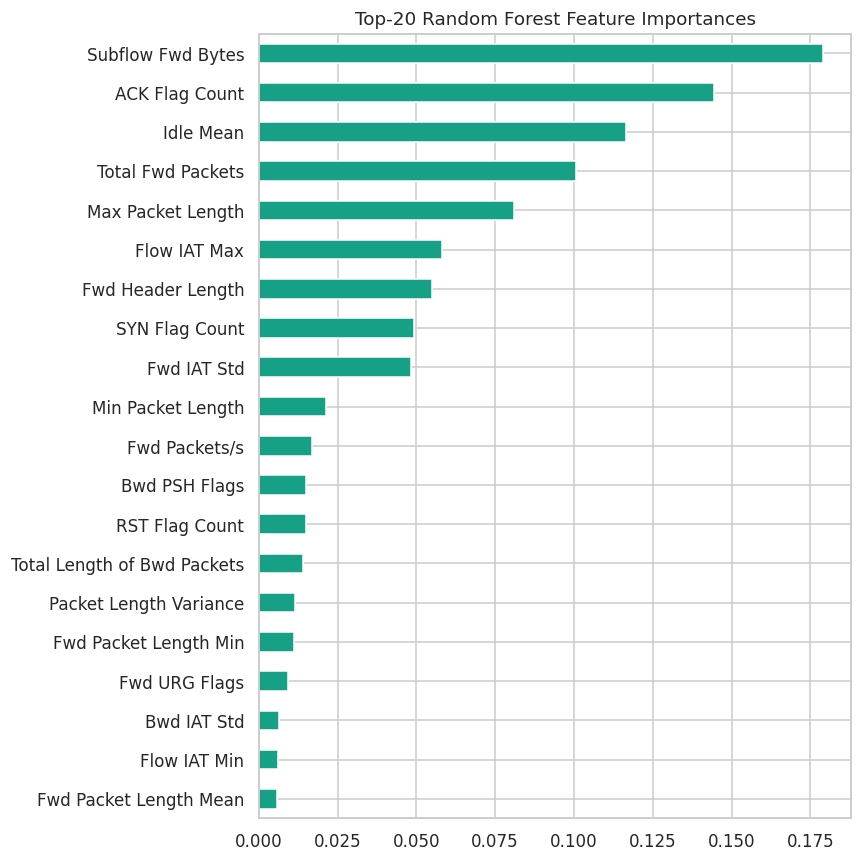

In [21]:

rf_sel = RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                  random_state=CONFIG.random_state, n_jobs=CONFIG.n_jobs)
rf_sel.fit(X_cr, y_bin)
importances = pd.Series(rf_sel.feature_importances_, index=X_cr.columns).sort_values(ascending=False)
importances.to_csv(CONFIG.metrics_dir / "06_rf_importance.csv")

fig, ax = plt.subplots(figsize=(8,8))
importances.head(20).sort_values().plot.barh(ax=ax, color="#16a085")
ax.set_title("Top-20 Random Forest Feature Importances")
fig.tight_layout(); fig.savefig(CONFIG.figures_dir / "06_rf_feature_importance.png"); plt.show()


In [22]:

mi = pd.Series(mutual_info_classif(X_cr, y_bin, random_state=CONFIG.random_state),
                index=X_cr.columns).sort_values(ascending=False)
mi.to_csv(CONFIG.metrics_dir / "06_mutual_info.csv")

TOP_K = min(25, X_cr.shape[1])
selected_features = sorted(set(importances.head(TOP_K).index) & set(mi.head(TOP_K).index)) or sorted(importances.head(TOP_K).index)
print(f"Selected {len(selected_features)} features (RF ∩ MI top-{TOP_K}):")
print(selected_features)
X_sel = X_cr[selected_features].copy()
utils.save_json({"selected_features":selected_features}, CONFIG.reports_dir/"06_selected_features.json")


Selected 22 features (RF ∩ MI top-25):
['ACK Flag Count', 'Bwd IAT Std', 'Bwd IAT Total', 'Bwd PSH Flags', 'Flow Bytes/s', 'Flow IAT Max', 'Flow IAT Min', 'Fwd Header Length', 'Fwd IAT Std', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packets/s', 'Fwd URG Flags', 'Idle Mean', 'Max Packet Length', 'Min Packet Length', 'Packet Length Variance', 'RST Flag Count', 'SYN Flag Count', 'Subflow Fwd Bytes', 'Total Fwd Packets', 'Total Length of Bwd Packets']


In [23]:

rfe = RFE(RandomForestClassifier(n_estimators=100, random_state=CONFIG.random_state,
                                   n_jobs=CONFIG.n_jobs),
          n_features_to_select=max(5,len(selected_features)//2))
rfe.fit(X_sel, y_bin)
rfe_rank = pd.Series(rfe.ranking_, index=X_sel.columns).sort_values()
print("RFE ranking (1=confirmed):"); print(rfe_rank.head(10))


RFE ranking (1=confirmed):
ACK Flag Count       1
Bwd PSH Flags        1
Fwd Header Length    1
Flow IAT Max         1
Idle Mean            1
Max Packet Length    1
Min Packet Length    1
Fwd IAT Std          1
SYN Flag Count       1
Total Fwd Packets    1
dtype: int64


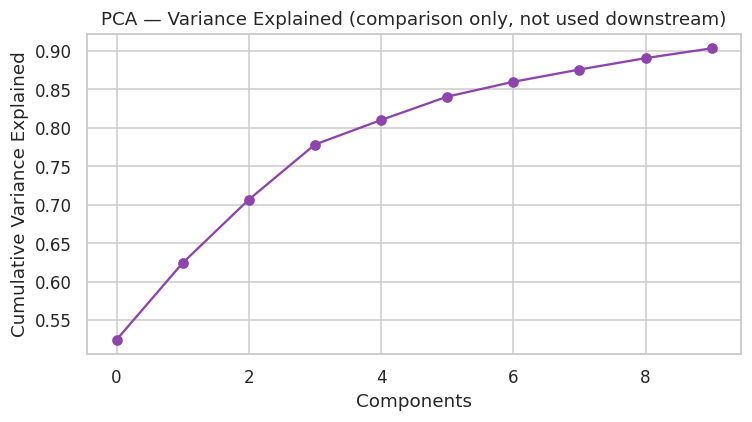

In [24]:

from sklearn.decomposition import PCA
pca_sc = StandardScaler().fit(X_sel)
pca = PCA(n_components=min(10,X_sel.shape[1]), random_state=CONFIG.random_state)
pca.fit(pca_sc.transform(X_sel))
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(np.cumsum(pca.explained_variance_ratio_),"o-",color="#8e44ad")
ax.set_xlabel("Components"); ax.set_ylabel("Cumulative Variance Explained")
ax.set_title("PCA — Variance Explained (comparison only, not used downstream)")
fig.tight_layout(); fig.savefig(CONFIG.figures_dir/"06_pca.png"); plt.show()



## 7. Handle Class Imbalance

Four strategies compared by 5-fold stratified-CV F1 on the training split only.
Resampling is NEVER applied to val, test, or the 2018 generalisation set.


In [25]:

X_tr0, X_tmp, y_tr0, y_tmp = train_test_split(
    X_sel, y_bin, test_size=CONFIG.test_size+CONFIG.val_size,
    stratify=y_bin, random_state=CONFIG.random_state)
rv = CONFIG.val_size / (CONFIG.test_size+CONFIG.val_size)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=1-rv, stratify=y_tmp, random_state=CONFIG.random_state)
print(f"Train:{X_tr0.shape}  Val:{X_val.shape}  Test:{X_test.shape}")


Train:(8317, 22)  Val:(1782, 22)  Test:(1783, 22)


In [26]:

sc0 = StandardScaler().fit(X_tr0)
Xtr0s = pd.DataFrame(sc0.transform(X_tr0), columns=X_tr0.columns, index=X_tr0.index)

strats = {
    "class_weight_balanced":  None,
    "random_oversampling":    RandomOverSampler(random_state=CONFIG.random_state),
    "smote":                  SMOTE(random_state=CONFIG.random_state,
                                    k_neighbors=min(5,y_tr0.value_counts().min()-1) or 1),
    "random_undersampling":   RandomUnderSampler(random_state=CONFIG.random_state),
}
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=CONFIG.random_state)
strat_scores = {}
for name, samp in strats.items():
    if samp is None:
        probe = RandomForestClassifier(n_estimators=100, class_weight="balanced",
                                        random_state=CONFIG.random_state, n_jobs=CONFIG.n_jobs)
        sc = cross_val_score(probe, Xtr0s, y_tr0, cv=cv5, scoring="f1", n_jobs=CONFIG.n_jobs)
    else:
        Xr,yr = samp.fit_resample(Xtr0s, y_tr0)
        probe = RandomForestClassifier(n_estimators=100, random_state=CONFIG.random_state, n_jobs=CONFIG.n_jobs)
        sc = cross_val_score(probe, Xr, yr, cv=cv5, scoring="f1", n_jobs=CONFIG.n_jobs)
    strat_scores[name] = float(sc.mean())
    print(f"{name:25s}  F1={sc.mean():.4f} ± {sc.std():.4f}")
utils.save_json(strat_scores, CONFIG.metrics_dir/"07_imbalance_cv.json")
BEST_STRAT = max(strat_scores, key=strat_scores.get)
print(f"\nSelected: {BEST_STRAT}")


class_weight_balanced      F1=1.0000 ± 0.0000


random_oversampling        F1=1.0000 ± 0.0000


smote                      F1=1.0000 ± 0.0000


random_undersampling       F1=1.0000 ± 0.0000

Selected: class_weight_balanced


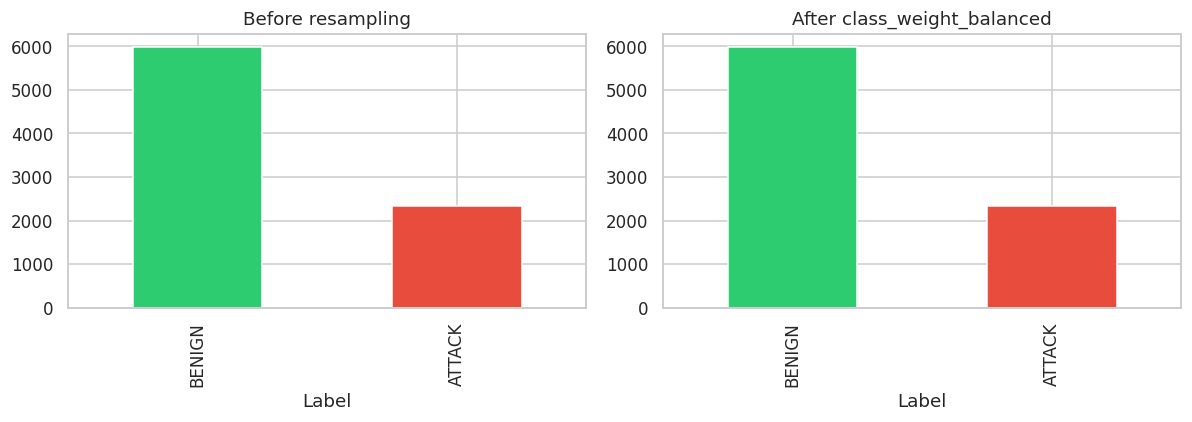

In [27]:

fig, axes = plt.subplots(1, 2, figsize=(11,4))
y_tr0.value_counts().rename({0:"BENIGN",1:"ATTACK"}).plot.bar(ax=axes[0], color=["#2ecc71","#e74c3c"])
axes[0].set_title("Before resampling")
if strats[BEST_STRAT] is not None:
    _, yp = strats[BEST_STRAT].fit_resample(Xtr0s, y_tr0)
else:
    yp = y_tr0
pd.Series(yp).value_counts().rename({0:"BENIGN",1:"ATTACK"}).plot.bar(ax=axes[1], color=["#2ecc71","#e74c3c"])
axes[1].set_title(f"After {BEST_STRAT}")
fig.tight_layout(); fig.savefig(CONFIG.figures_dir/"07_class_balance.png"); plt.show()


## 8. Final Leakage-Safe Train/Val/Test Split

In [28]:

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X_sel, y_bin, test_size=CONFIG.test_size+CONFIG.val_size,
    stratify=y_bin, random_state=CONFIG.random_state)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=1-rv, stratify=y_tmp, random_state=CONFIG.random_state)

scaler = StandardScaler().fit(X_train)   # fit ONLY on train
X_train_s = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
X_val_s   = pd.DataFrame(scaler.transform(X_val),   columns=X_val.columns,   index=X_val.index)
X_test_s  = pd.DataFrame(scaler.transform(X_test),  columns=X_test.columns,  index=X_test.index)
joblib.dump(scaler, CONFIG.models_dir / "feature_scaler.joblib")

if BEST_STRAT == "class_weight_balanced":
    X_tf, y_tf = X_train_s, y_train
else:
    X_tf, y_tf = strats[BEST_STRAT].fit_resample(X_train_s, y_train)
print(f"Train (post-resample): {X_tf.shape}  Val: {X_val_s.shape}  Test: {X_test_s.shape}")


Train (post-resample): (8317, 22)  Val: (1782, 22)  Test: (1783, 22)



## 9. Model Development — All 6 Classical Models + Neural Network

Each model is trained with:
- A scikit-learn Pipeline (prevents scaling leakage)
- RandomizedSearchCV hyperparameter tuning
- 3-fold stratified cross-validation
- Trained on the balanced training set
- Evaluated on the held-out test set (Section 13)


In [29]:

model_results  = {}
trained_models = {}
training_times = {}


### 9.1 Logistic Regression — Interpretable Linear Baseline

In [30]:

lr_pipe = Pipeline([("clf", LogisticRegression(class_weight="balanced",
                                                 max_iter=1000,
                                                 random_state=CONFIG.random_state,
                                                 n_jobs=CONFIG.n_jobs))])
lr_params = {"clf__C": [0.01, 0.1, 1, 10, 100], "clf__solver": ["lbfgs","liblinear"]}
lr_search = RandomizedSearchCV(lr_pipe, lr_params, n_iter=6, cv=3, scoring="f1",
                                random_state=CONFIG.random_state, n_jobs=CONFIG.n_jobs)
with utils.Timer() as t:
    lr_search.fit(X_tf, y_tf)
training_times["Logistic Regression"] = t.elapsed
print(f"LR best params: {lr_search.best_params_}  CV F1={lr_search.best_score_:.4f}  {t.elapsed:.1f}s")
trained_models["Logistic Regression"] = lr_search.best_estimator_
utils.save_model(lr_search.best_estimator_, CONFIG.models_dir/"logistic_regression.joblib")


LR best params: {'clf__solver': 'lbfgs', 'clf__C': 100}  CV F1=1.0000  0.3s


### 9.2 Decision Tree — Fully Interpretable Rule-Based Classifier

In [31]:

dt_pipe = Pipeline([("clf", DecisionTreeClassifier(class_weight="balanced",
                                                     random_state=CONFIG.random_state))])
dt_params = {"clf__max_depth":[5,10,20,None],
              "clf__min_samples_split":[2,5,10],
              "clf__criterion":["gini","entropy"]}
dt_search = RandomizedSearchCV(dt_pipe, dt_params, n_iter=8, cv=3, scoring="f1",
                                random_state=CONFIG.random_state, n_jobs=CONFIG.n_jobs)
with utils.Timer() as t:
    dt_search.fit(X_tf, y_tf)
training_times["Decision Tree"] = t.elapsed
print(f"DT best params: {dt_search.best_params_}  CV F1={dt_search.best_score_:.4f}  {t.elapsed:.1f}s")
trained_models["Decision Tree"] = dt_search.best_estimator_
utils.save_model(dt_search.best_estimator_, CONFIG.models_dir/"decision_tree.joblib")


DT best params: {'clf__min_samples_split': 10, 'clf__max_depth': 20, 'clf__criterion': 'gini'}  CV F1=0.9998  0.6s


### 9.3 Naive Bayes — Probabilistic Baseline (Feature Independence Test)

In [32]:

# GaussianNB has no hyperparameters worth tuning — single fit
with utils.Timer() as t:
    nb_model = GaussianNB()
    nb_model.fit(X_tf.values if hasattr(X_tf,"values") else X_tf, y_tf.values if hasattr(y_tf,"values") else y_tf)
training_times["Naive Bayes"] = t.elapsed
print(f"NB trained in {t.elapsed:.2f}s")
nb_pipe = Pipeline([("clf", nb_model)])   # wrap for uniform API
trained_models["Naive Bayes"] = nb_model
utils.save_model(nb_model, CONFIG.models_dir/"naive_bayes.joblib")


NB trained in 0.00s


### 9.4 Random Forest — Primary Tree Ensemble (used for SHAP explainability)

In [33]:

rf_pipe = Pipeline([("clf", RandomForestClassifier(random_state=CONFIG.random_state,
                                                     n_jobs=CONFIG.n_jobs))])
rf_params = {"clf__n_estimators":[200,400],
              "clf__max_depth":[None,20,40],
              "clf__min_samples_split":[2,5]}
rf_search = RandomizedSearchCV(rf_pipe, rf_params, n_iter=6, cv=3, scoring="f1",
                                random_state=CONFIG.random_state, n_jobs=CONFIG.n_jobs)
with utils.Timer() as t:
    rf_search.fit(X_tf, y_tf)
training_times["Random Forest"] = t.elapsed
print(f"RF best params: {rf_search.best_params_}  CV F1={rf_search.best_score_:.4f}  {t.elapsed:.1f}s")
trained_models["Random Forest"] = rf_search.best_estimator_
utils.save_model(rf_search.best_estimator_, CONFIG.models_dir/"random_forest.joblib")


RF best params: {'clf__n_estimators': 200, 'clf__min_samples_split': 5, 'clf__max_depth': 40}  CV F1=1.0000  23.7s


### 9.5 SVM — Maximum-Margin High-Dimensional Separator

In [34]:

MAX_SVM = 6000
if len(X_tf) > MAX_SVM:
    sX, _, sy, _ = train_test_split(X_tf, y_tf, train_size=MAX_SVM,
                                     stratify=y_tf, random_state=CONFIG.random_state)
else:
    sX, sy = X_tf, y_tf
print(f"SVM training on {len(sX)} samples (scalability cap = {MAX_SVM})")

svm_pipe = Pipeline([("clf", SVC(probability=True, random_state=CONFIG.random_state))])
svm_params = {"clf__C":[1,10,50],"clf__gamma":["scale","auto"]}
svm_search = RandomizedSearchCV(svm_pipe, svm_params, n_iter=4, cv=3, scoring="f1",
                                 random_state=CONFIG.random_state, n_jobs=CONFIG.n_jobs)
with utils.Timer() as t:
    svm_search.fit(sX, sy)
training_times["SVM"] = t.elapsed
print(f"SVM best params: {svm_search.best_params_}  CV F1={svm_search.best_score_:.4f}  {t.elapsed:.1f}s")
trained_models["SVM"] = svm_search.best_estimator_
utils.save_model(svm_search.best_estimator_, CONFIG.models_dir/"svm.joblib")


SVM training on 6000 samples (scalability cap = 6000)


SVM best params: {'clf__gamma': 'scale', 'clf__C': 1}  CV F1=1.0000  1.4s


### 9.6 XGBoost — Gradient-Boosted Trees with Regularisation

In [35]:

# scale_pos_weight handles class imbalance natively (ratio of negatives to positives)
neg_pos_ratio = float((y_tf==0).sum()) / max(float((y_tf==1).sum()), 1)
xgb_pipe = Pipeline([("clf", xgb.XGBClassifier(
    scale_pos_weight=neg_pos_ratio,
    use_label_encoder=False, eval_metric="logloss",
    random_state=CONFIG.random_state, n_jobs=CONFIG.n_jobs,
    verbosity=0))])
xgb_params = {
    "clf__n_estimators":[200,400],
    "clf__max_depth":[4,6,8],
    "clf__learning_rate":[0.05,0.1,0.2],
    "clf__subsample":[0.8,1.0],
    "clf__reg_alpha":[0,0.1],
    "clf__reg_lambda":[1,2],
}
xgb_search = RandomizedSearchCV(xgb_pipe, xgb_params, n_iter=8, cv=3, scoring="f1",
                                 random_state=CONFIG.random_state, n_jobs=CONFIG.n_jobs)
with utils.Timer() as t:
    xgb_search.fit(X_tf, y_tf)
training_times["XGBoost"] = t.elapsed
print(f"XGB best params: {xgb_search.best_params_}  CV F1={xgb_search.best_score_:.4f}  {t.elapsed:.1f}s")
trained_models["XGBoost"] = xgb_search.best_estimator_
utils.save_model(xgb_search.best_estimator_, CONFIG.models_dir/"xgboost.joblib")


XGB best params: {'clf__subsample': 1.0, 'clf__reg_lambda': 1, 'clf__reg_alpha': 0.1, 'clf__n_estimators': 200, 'clf__max_depth': 6, 'clf__learning_rate': 0.2}  CV F1=1.0000  3.4s



## 10. Neural Network (TensorFlow/Keras)
Dense → BatchNormalization → Dropout blocks with EarlyStopping,
ModelCheckpoint and ReduceLROnPlateau scheduling.


In [36]:

def build_nn(input_dim, seed=42):
    tf.random.set_seed(seed)
    inp = Input(shape=(input_dim,))
    x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    m = Model(inp, out)
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
               loss="binary_crossentropy",
               metrics=["accuracy", tf.keras.metrics.AUC(name="auc")])
    return m

nn = build_nn(X_tf.shape[1], CONFIG.random_state)
nn.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 22)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,209 (55.50 KB)

 Trainable params: 13,761 (53.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [37]:

ckpt = CONFIG.models_dir / "neural_network_best.keras"
nn_cbs = [
    callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    callbacks.ModelCheckpoint(str(ckpt), monitor="val_loss", save_best_only=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6),
]
Xt_arr = X_tf.values if hasattr(X_tf,"values") else X_tf
yt_arr = y_tf.values if hasattr(y_tf,"values") else y_tf
with utils.Timer() as t:
    hist = nn.fit(Xt_arr, yt_arr,
                   validation_data=(X_val_s.values, y_val.values),
                   epochs=60, batch_size=256, callbacks=nn_cbs, verbose=0)
training_times["Neural Network"] = t.elapsed
trained_models["Neural Network"] = nn
print(f"NN trained {len(hist.history['loss'])} epochs in {t.elapsed:.1f}s")


NN trained 60 epochs in 17.7s


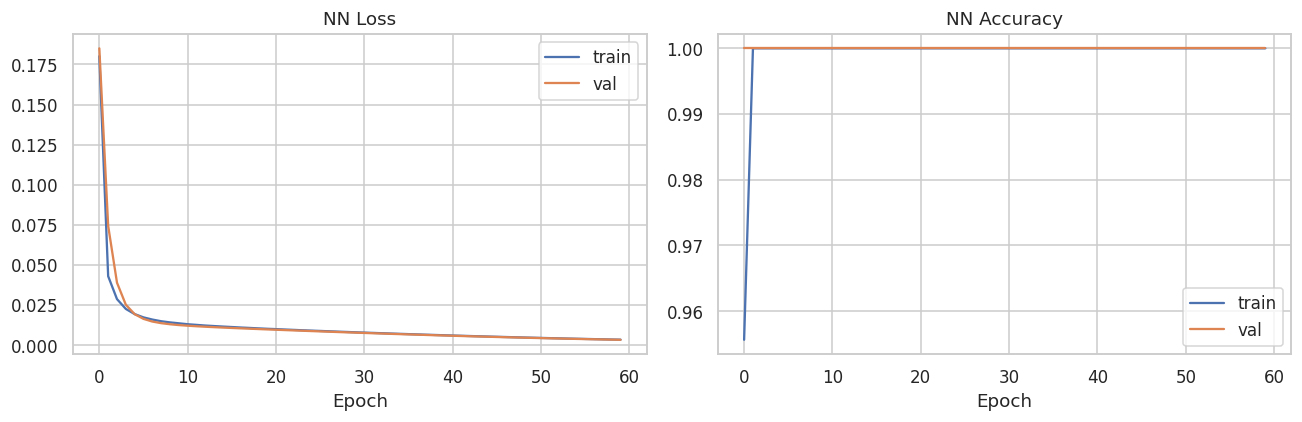

In [38]:

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(hist.history["loss"],label="train"); axes[0].plot(hist.history["val_loss"],label="val")
axes[0].set_title("NN Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(hist.history["accuracy"],label="train"); axes[1].plot(hist.history["val_accuracy"],label="val")
axes[1].set_title("NN Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()
fig.tight_layout(); fig.savefig(CONFIG.figures_dir/"10_nn_training_history.png"); plt.show()


## 11. Hyperparameter Optimisation — Tuned vs Untuned Comparison

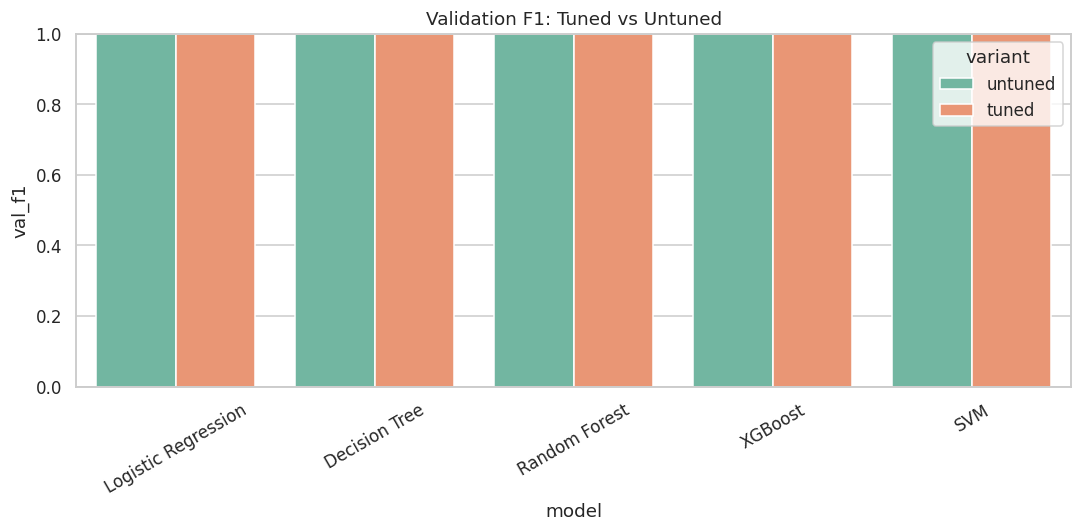

,model,variant,val_f1
0,Logistic Regression,untuned,1.0
1,Logistic Regression,tuned,1.0
2,Decision Tree,untuned,1.0
3,Decision Tree,tuned,1.0
4,Random Forest,untuned,1.0
5,Random Forest,tuned,1.0
6,XGBoost,untuned,1.0
7,XGBoost,tuned,1.0
8,SVM,untuned,1.0
9,SVM,tuned,1.0


In [39]:

baselines = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000,
                                               random_state=CONFIG.random_state).fit(X_tf, y_tf),
    "Decision Tree":       DecisionTreeClassifier(class_weight="balanced",
                                                   random_state=CONFIG.random_state).fit(X_tf, y_tf),
    "Random Forest":       RandomForestClassifier(random_state=CONFIG.random_state,
                                                   n_jobs=CONFIG.n_jobs).fit(X_tf, y_tf),
    "XGBoost":             xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss",
                                              verbosity=0, random_state=CONFIG.random_state).fit(X_tf, y_tf),
    "SVM":                 SVC(probability=True, random_state=CONFIG.random_state).fit(sX, sy),
}
rows = []
for mname, base in baselines.items():
    tuned = trained_models[mname]
    rows.append({"model":mname,"variant":"untuned","val_f1":f1_score(y_val,base.predict(X_val_s),zero_division=0)})
    rows.append({"model":mname,"variant":"tuned",  "val_f1":f1_score(y_val,tuned.predict(X_val_s),zero_division=0)})
tdf = pd.DataFrame(rows)
tdf.to_csv(CONFIG.metrics_dir/"11_tuning_comparison.csv", index=False)
fig, ax = plt.subplots(figsize=(10,5))
sns.barplot(data=tdf, x="model", y="val_f1", hue="variant", ax=ax, palette="Set2")
ax.set_title("Validation F1: Tuned vs Untuned"); ax.set_ylim(0,1)
ax.tick_params(axis="x", rotation=30)
fig.tight_layout(); fig.savefig(CONFIG.figures_dir/"11_tuning_comparison.png"); plt.show()
tdf



## 12. Ensemble Model

Two ensemble strategies are tried:
1. **Soft-voting** (RF + SVM + XGBoost + Neural Network probability averaging) — each
   model contributes its attack-class probability, the mean is the ensemble score
2. **Stacking** (RF + XGBoost as base learners, Logistic Regression as meta-learner)

The strategy with the higher validation F1 is selected.


In [40]:

class KerasProbaWrapper:
    '''Minimal sklearn-compatible wrapper for soft-voting with a Keras model.'''
    def __init__(self, m):
        self.m = m; self.classes_ = np.array([0,1])
    def predict_proba(self, X):
        p1 = self.m.predict(np.asarray(X), verbose=0).ravel()
        return np.column_stack([1-p1,p1])
    def predict(self, X):
        return (self.predict_proba(X)[:,1]>=0.5).astype(int)

nn_wrapped = KerasProbaWrapper(trained_models["Neural Network"])

def soft_vote(models_dict, X):
    return np.mean([m.predict_proba(X)[:,1] for m in models_dict.values()], axis=0)

sv_members = {
    "Random Forest": trained_models["Random Forest"],
    "SVM":           trained_models["SVM"],
    "XGBoost":       trained_models["XGBoost"],
    "Neural Network":nn_wrapped,
}
sv_proba_val = soft_vote(sv_members, X_val_s)
sv_f1 = f1_score(y_val, (sv_proba_val>=0.5).astype(int))
print(f"Soft-voting validation F1: {sv_f1:.4f}")


Soft-voting validation F1: 1.0000


In [41]:

n_stk = min(MAX_SVM, len(X_tf))
stk_X = X_tf.sample(n_stk, random_state=CONFIG.random_state)
stk_y = y_tf.loc[stk_X.index] if hasattr(y_tf,"loc") else y_tf[:n_stk]
stacking = StackingClassifier(
    estimators=[
        ("rf",  RandomForestClassifier(n_estimators=200, random_state=CONFIG.random_state, n_jobs=CONFIG.n_jobs)),
        ("xgb", xgb.XGBClassifier(n_estimators=200, use_label_encoder=False,
                                    eval_metric="logloss", verbosity=0,
                                    random_state=CONFIG.random_state, n_jobs=CONFIG.n_jobs)),
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=3, n_jobs=CONFIG.n_jobs,
)
with utils.Timer() as t:
    stacking.fit(stk_X, stk_y)
stk_f1 = f1_score(y_val, stacking.predict(X_val_s))
print(f"Stacking validation F1: {stk_f1:.4f}  ({t.elapsed:.1f}s)")

if sv_f1 >= stk_f1:
    ENSEMBLE_STRAT = "soft_voting"
    print("Selected: SOFT VOTING (RF + SVM + XGBoost + NN)")
else:
    ENSEMBLE_STRAT = "stacking"
    trained_models["Ensemble"] = stacking
    print("Selected: STACKING (RF + XGBoost, LR meta-learner)")


Stacking validation F1: 1.0000  (3.4s)
Selected: SOFT VOTING (RF + SVM + XGBoost + NN)


## 13. Model Evaluation — CICIDS2017 Internal Test Set

In [42]:

def get_proba(name, X):
    m = trained_models[name]
    if name == "Naive Bayes":
        return m.predict_proba(X.values if hasattr(X,"values") else X)[:,1]
    return m.predict_proba(X)[:,1]

def evaluate_store(name, y_pred, y_proba):
    m = utils.compute_classification_metrics(y_test.values, y_pred, y_proba)
    model_results[name] = m
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    for k,v in m.items():
        if isinstance(v,float): print(f"  {k:25s}: {v:.4f}")
    print(classification_report(y_test, y_pred, target_names=["BENIGN","ATTACK"], zero_division=0))

# All 6 classical models
for mname in ["Logistic Regression","Decision Tree","Naive Bayes",
               "Random Forest","SVM","XGBoost"]:
    yp = get_proba(mname, X_test_s)
    ypred = trained_models[mname].predict(
        X_test_s.values if mname=="Naive Bayes" else X_test_s)
    evaluate_store(mname, ypred, yp)

# Neural Network
nn_proba = nn_wrapped.predict_proba(X_test_s)[:,1]
nn_pred  = (nn_proba>=0.5).astype(int)
evaluate_store("Neural Network", nn_pred, nn_proba)

# Ensemble
if ENSEMBLE_STRAT == "soft_voting":
    ens_proba = soft_vote(sv_members, X_test_s)
else:
    ens_proba = trained_models["Ensemble"].predict_proba(X_test_s)[:,1]
ens_pred = (ens_proba>=0.5).astype(int)
evaluate_store("Ensemble", ens_pred, ens_proba)

metrics_df = pd.DataFrame(model_results).T
metrics_df.to_csv(CONFIG.metrics_dir/"13_all_model_metrics.csv")
metrics_df



  Logistic Regression
  accuracy                 : 1.0000
  precision                : 1.0000
  recall                   : 1.0000
  f1_score                 : 1.0000
  specificity              : 1.0000
  sensitivity              : 1.0000
  false_positive_rate      : 0.0000
  false_negative_rate      : 0.0000
  balanced_accuracy        : 1.0000
  matthews_corrcoef        : 1.0000
  cohen_kappa              : 1.0000
  roc_auc                  : 1.0000
  pr_auc                   : 1.0000
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00      1283
      ATTACK       1.00      1.00      1.00       500

    accuracy                           1.00      1783
   macro avg       1.00      1.00      1.00      1783
weighted avg       1.00      1.00      1.00      1783


  Decision Tree
  accuracy                 : 1.0000
  precision                : 1.0000
  recall                   : 1.0000
  f1_score                 : 1.0000
  specificity        


  Neural Network
  accuracy                 : 1.0000
  precision                : 1.0000
  recall                   : 1.0000
  f1_score                 : 1.0000
  specificity              : 1.0000
  sensitivity              : 1.0000
  false_positive_rate      : 0.0000
  false_negative_rate      : 0.0000
  balanced_accuracy        : 1.0000
  matthews_corrcoef        : 1.0000
  cohen_kappa              : 1.0000
  roc_auc                  : 1.0000
  pr_auc                   : 1.0000
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00      1283
      ATTACK       1.00      1.00      1.00       500

    accuracy                           1.00      1783
   macro avg       1.00      1.00      1.00      1783
weighted avg       1.00      1.00      1.00      1783




  Ensemble
  accuracy                 : 1.0000
  precision                : 1.0000
  recall                   : 1.0000
  f1_score                 : 1.0000
  specificity              : 1.0000
  sensitivity              : 1.0000
  false_positive_rate      : 0.0000
  false_negative_rate      : 0.0000
  balanced_accuracy        : 1.0000
  matthews_corrcoef        : 1.0000
  cohen_kappa              : 1.0000
  roc_auc                  : 1.0000
  pr_auc                   : 1.0000
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00      1283
      ATTACK       1.00      1.00      1.00       500

    accuracy                           1.00      1783
   macro avg       1.00      1.00      1.00      1783
weighted avg       1.00      1.00      1.00      1783



,accuracy,precision,recall,f1_score,specificity,sensitivity,false_positive_rate,false_negative_rate,balanced_accuracy,matthews_corrcoef,cohen_kappa,true_negative,false_positive,false_negative,true_positive,roc_auc,pr_auc
Logistic Regression,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1283.0,0.0,0.0,500.0,1.0,1.0
Decision Tree,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1283.0,0.0,0.0,500.0,1.0,1.0
Naive Bayes,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1283.0,0.0,0.0,500.0,1.0,1.0
Random Forest,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1283.0,0.0,0.0,500.0,1.0,1.0
SVM,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1283.0,0.0,0.0,500.0,1.0,1.0
XGBoost,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1283.0,0.0,0.0,500.0,1.0,1.0
Neural Network,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1283.0,0.0,0.0,500.0,1.0,1.0
Ensemble,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1283.0,0.0,0.0,500.0,1.0,1.0


## 14. Visualisations — All Models Compared

In [43]:

# Build lookup dicts
proba_lkp = {n: model_results[n].get("roc_auc",0) for n in model_results}
pred_lkp = {}
for mname in ["Logistic Regression","Decision Tree","Naive Bayes",
               "Random Forest","SVM","XGBoost"]:
    pred_lkp[mname] = trained_models[mname].predict(
        X_test_s.values if mname=="Naive Bayes" else X_test_s)
pred_lkp["Neural Network"] = nn_pred
pred_lkp["Ensemble"] = ens_pred

proba_full = {}
for mname in ["Logistic Regression","Decision Tree","Naive Bayes",
               "Random Forest","SVM","XGBoost"]:
    proba_full[mname] = get_proba(mname, X_test_s)
proba_full["Neural Network"] = nn_proba
proba_full["Ensemble"] = ens_proba


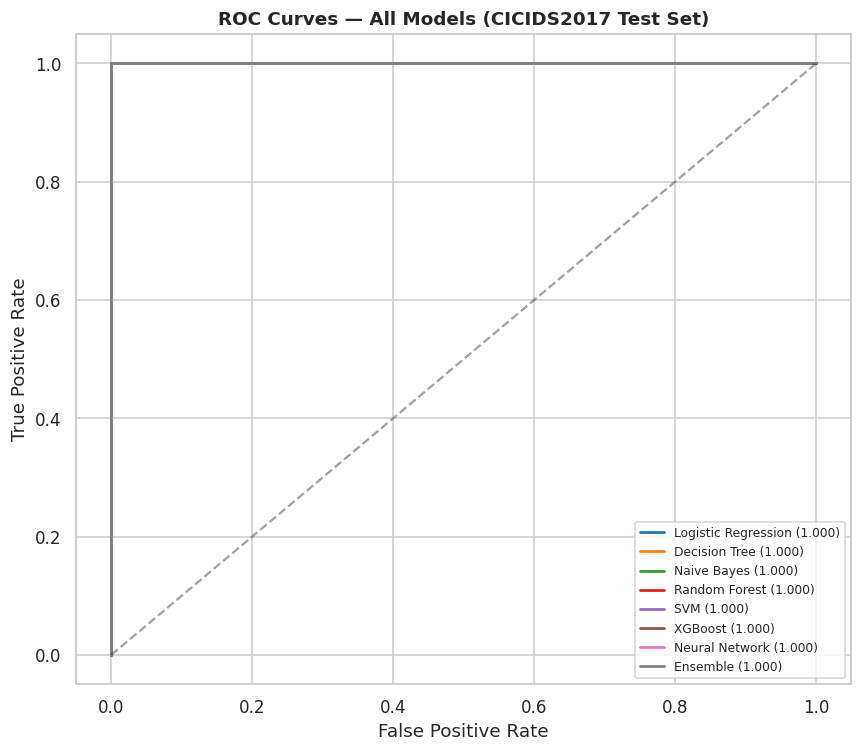

In [44]:

# ROC Curves — all models
palette = sns.color_palette("tab10", len(proba_full))
fig, ax = plt.subplots(figsize=(8,7))
for (name,proba),col in zip(proba_full.items(), palette):
    c = utils.get_roc_pr_curve_data(y_test.values, proba)
    auc_v = model_results[name].get("roc_auc",float("nan"))
    ax.plot(c["fpr"], c["tpr"], color=col, label=f"{name} ({auc_v:.3f})", linewidth=1.8)
ax.plot([0,1],[0,1],"k--",alpha=0.4)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Models (CICIDS2017 Test Set)", fontweight="bold")
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout(); fig.savefig(CONFIG.figures_dir/"14_roc_curves_all.png"); plt.show()


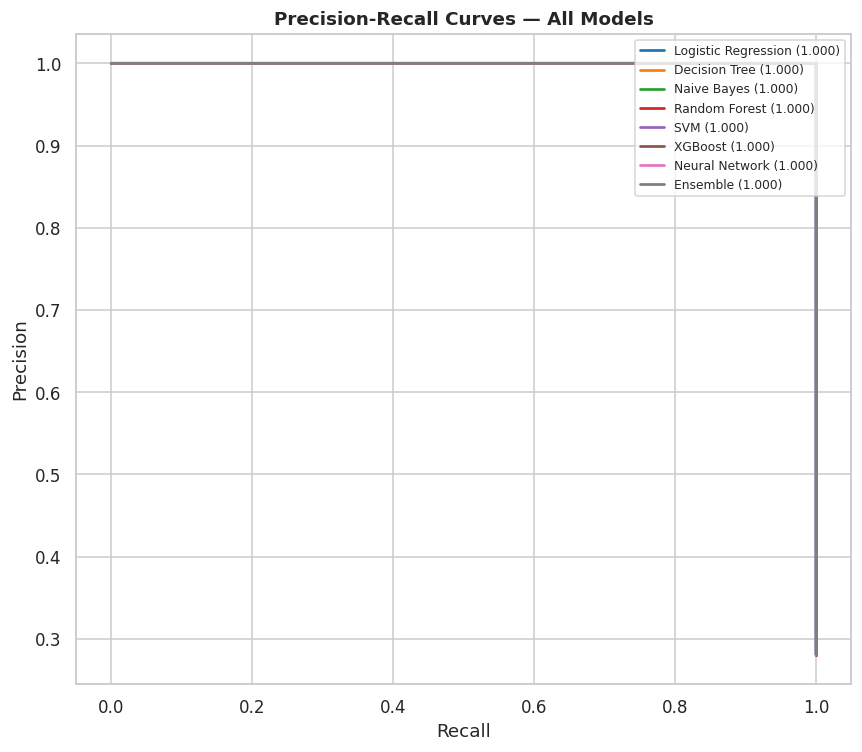

In [45]:

# PR Curves
fig, ax = plt.subplots(figsize=(8,7))
for (name,proba),col in zip(proba_full.items(), palette):
    c = utils.get_roc_pr_curve_data(y_test.values, proba)
    pr_auc = model_results[name].get("pr_auc",float("nan"))
    ax.plot(c["recall"], c["precision"], color=col, label=f"{name} ({pr_auc:.3f})", linewidth=1.8)
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves — All Models", fontweight="bold")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout(); fig.savefig(CONFIG.figures_dir/"14_pr_curves_all.png"); plt.show()


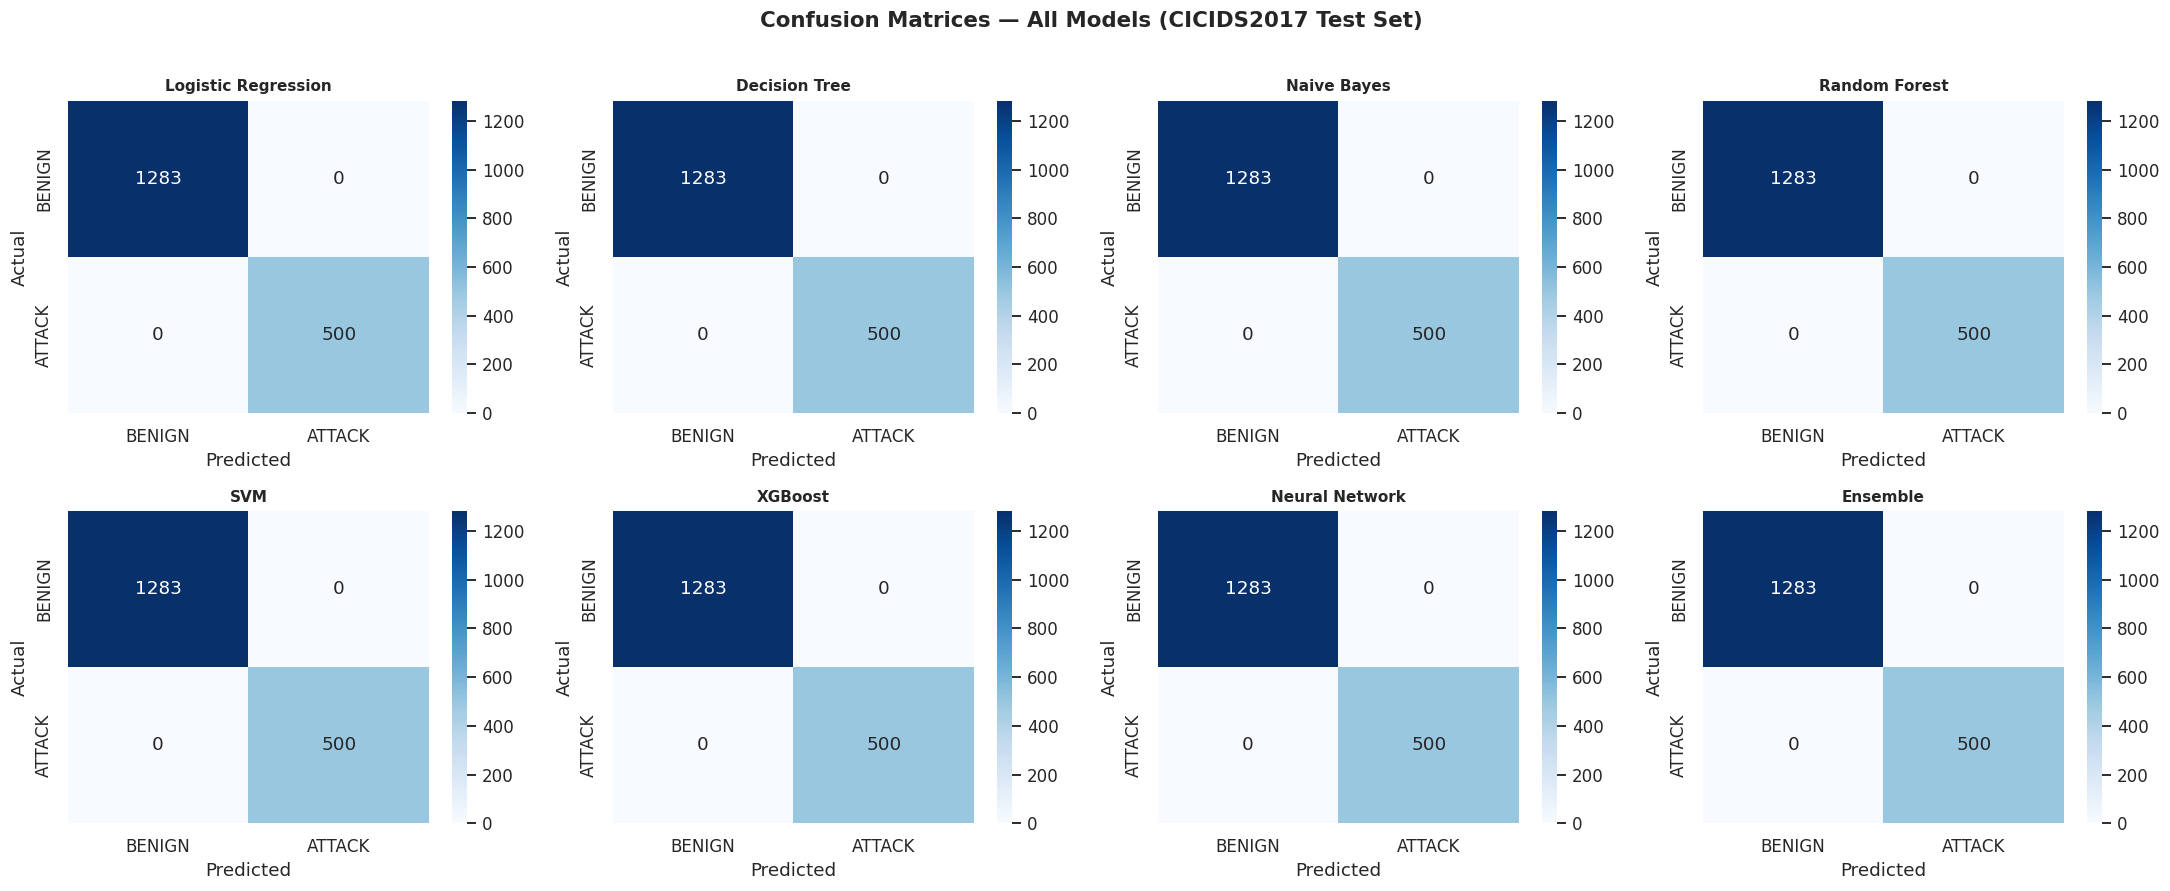

In [46]:

# Confusion matrices — 3x3 grid for all 8 models+ensemble
model_names_all = list(pred_lkp.keys())
n_models = len(model_names_all)
ncols = 4; nrows = (n_models + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes_flat = axes.ravel() if nrows>1 else axes
for i, (name, pred) in enumerate(pred_lkp.items()):
    cm = confusion_matrix(y_test, pred, labels=[0,1])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes_flat[i],
                xticklabels=["BENIGN","ATTACK"], yticklabels=["BENIGN","ATTACK"])
    axes_flat[i].set_title(name, fontsize=10, fontweight="bold")
    axes_flat[i].set_xlabel("Predicted"); axes_flat[i].set_ylabel("Actual")
for j in range(i+1, len(axes_flat)):
    axes_flat[j].set_visible(False)
fig.suptitle("Confusion Matrices — All Models (CICIDS2017 Test Set)", fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout(); fig.savefig(CONFIG.figures_dir/"14_confusion_matrices_all.png", bbox_inches="tight"); plt.show()


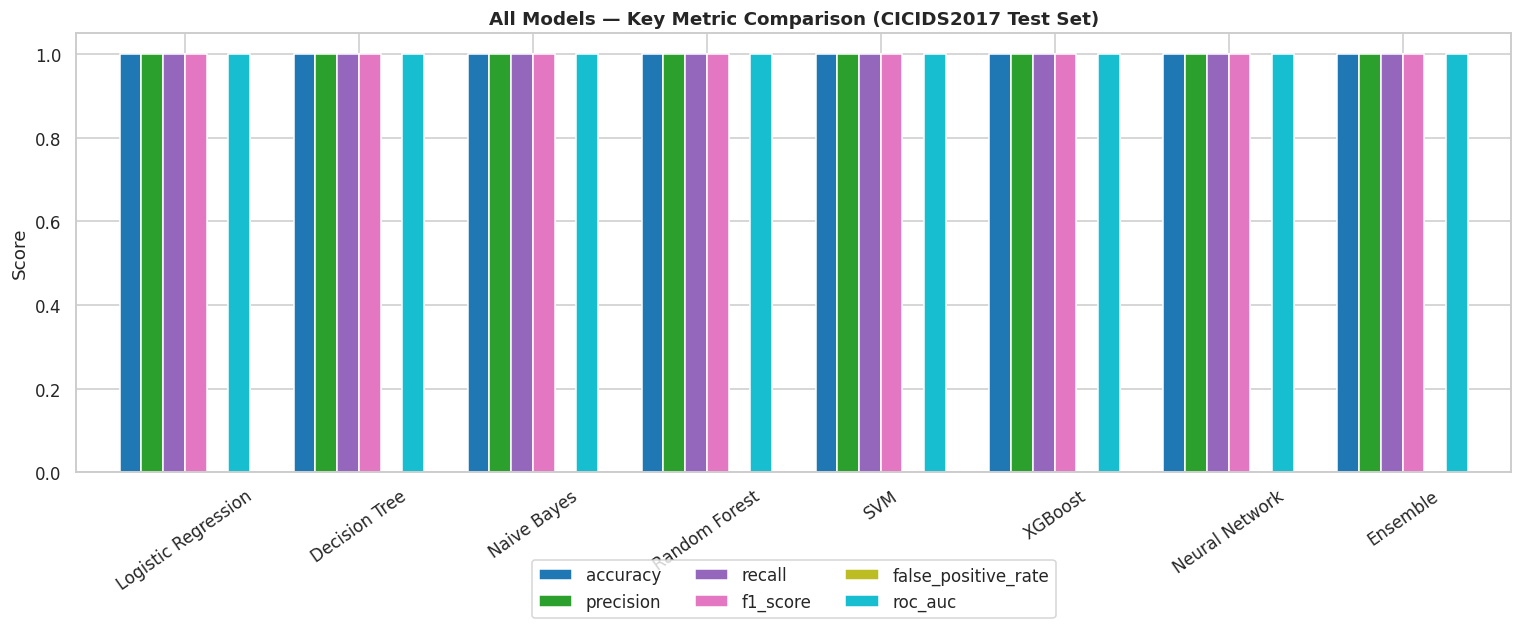

In [47]:

# Model comparison bar chart — key metrics
compare_cols = ["accuracy","precision","recall","f1_score","false_positive_rate","roc_auc"]
fig, ax = plt.subplots(figsize=(14,6))
metrics_df[compare_cols].astype(float).plot(kind="bar", ax=ax, colormap="tab10", width=0.75)
ax.set_title("All Models — Key Metric Comparison (CICIDS2017 Test Set)", fontweight="bold")
ax.set_ylabel("Score"); ax.set_ylim(0,1.05)
ax.legend(loc="upper center", bbox_to_anchor=(0.5,-0.18), ncol=3)
ax.tick_params(axis="x", rotation=35)
fig.tight_layout(); fig.savefig(CONFIG.figures_dir/"14_all_models_comparison.png"); plt.show()


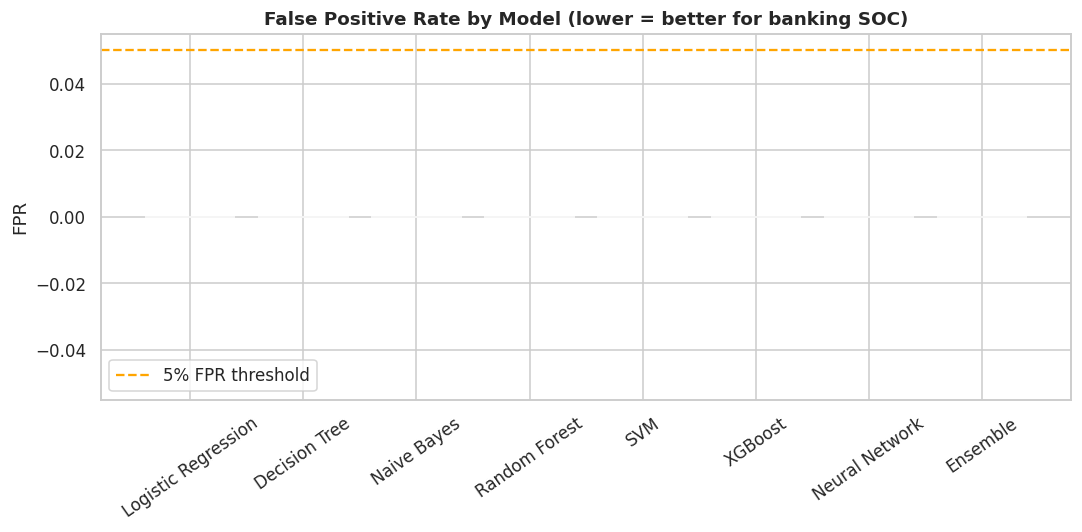

In [48]:

# False Positive Rate bar chart — highlighted (key banking metric)
fpr_series = metrics_df["false_positive_rate"].astype(float).sort_values()
fig, ax = plt.subplots(figsize=(10,5))
colors = ["#e74c3c" if v>0.05 else "#2ecc71" for v in fpr_series]
ax.bar(fpr_series.index, fpr_series, color=colors)
ax.axhline(0.05, color="orange", linestyle="--", label="5% FPR threshold")
ax.set_title("False Positive Rate by Model (lower = better for banking SOC)", fontweight="bold")
ax.set_ylabel("FPR"); ax.tick_params(axis="x", rotation=35)
ax.legend()
fig.tight_layout(); fig.savefig(CONFIG.figures_dir/"14_fpr_comparison.png"); plt.show()


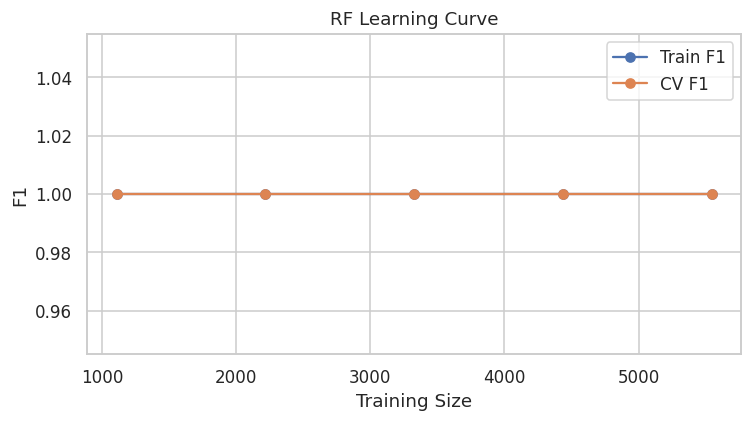

In [49]:

# Learning curve — Random Forest
tr_sz, tr_sc, vl_sc = learning_curve(
    RandomForestClassifier(n_estimators=200, random_state=CONFIG.random_state, n_jobs=CONFIG.n_jobs),
    X_tf, y_tf, cv=3, scoring="f1",
    train_sizes=np.linspace(0.2,1.0,5), n_jobs=CONFIG.n_jobs)
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(tr_sz, tr_sc.mean(axis=1),"o-",label="Train F1")
ax.plot(tr_sz, vl_sc.mean(axis=1),"o-",label="CV F1")
ax.set_xlabel("Training Size"); ax.set_ylabel("F1"); ax.set_title("RF Learning Curve"); ax.legend()
fig.tight_layout(); fig.savefig(CONFIG.figures_dir/"14_rf_learning_curve.png"); plt.show()


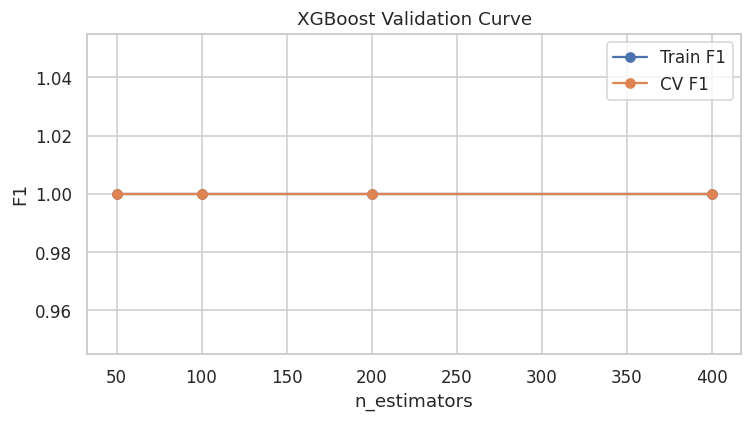

In [50]:

# Validation curve — XGBoost n_estimators
xgb_base = xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss",
                               verbosity=0, random_state=CONFIG.random_state, n_jobs=CONFIG.n_jobs)
p_range = [50,100,200,400]
tr_vc, vl_vc = validation_curve(xgb_base, X_tf, y_tf,
                                 param_name="n_estimators", param_range=p_range,
                                 cv=3, scoring="f1", n_jobs=CONFIG.n_jobs)
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(p_range, tr_vc.mean(axis=1),"o-",label="Train F1")
ax.plot(p_range, vl_vc.mean(axis=1),"o-",label="CV F1")
ax.set_xlabel("n_estimators"); ax.set_ylabel("F1"); ax.set_title("XGBoost Validation Curve"); ax.legend()
fig.tight_layout(); fig.savefig(CONFIG.figures_dir/"14_xgb_validation_curve.png"); plt.show()


## 15. Explainable AI — SHAP (Random Forest) & LIME (all major cases)

In [51]:

RF_MODEL = trained_models["Random Forest"]
RF_RAW = RF_MODEL.named_steps["clf"] if hasattr(RF_MODEL,"named_steps") else RF_MODEL
shap_sample = X_test_s.sample(n=min(300,len(X_test_s)), random_state=CONFIG.random_state)
explainer = shap.TreeExplainer(RF_RAW)
shap_vals = explainer.shap_values(shap_sample)
sv_atk = shap_vals[...,1] if isinstance(shap_vals,np.ndarray) and shap_vals.ndim==3 else shap_vals[1]
print("SHAP values computed. Shape:", np.array(sv_atk).shape)


SHAP values computed. Shape: (300, 22)


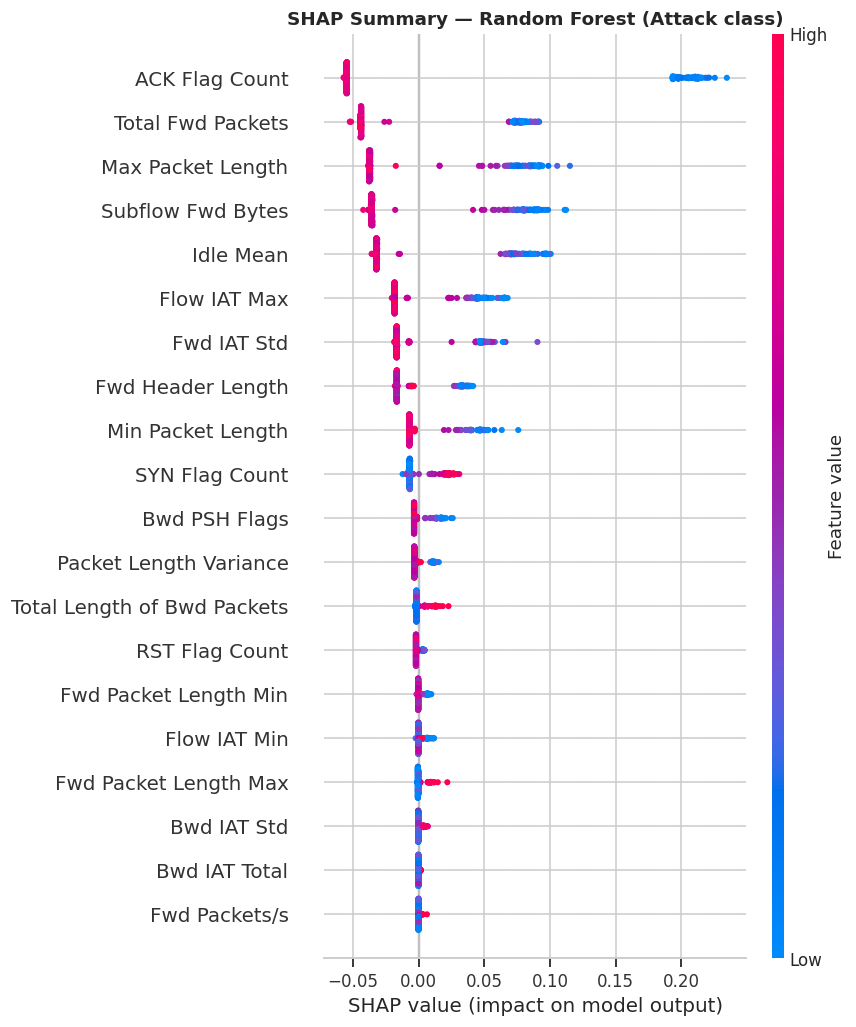

In [52]:

plt.figure()
shap.summary_plot(sv_atk, shap_sample, show=False)
plt.title("SHAP Summary — Random Forest (Attack class)", fontweight="bold")
plt.tight_layout(); plt.savefig(CONFIG.figures_dir/"15_shap_summary.png", bbox_inches="tight"); plt.show()


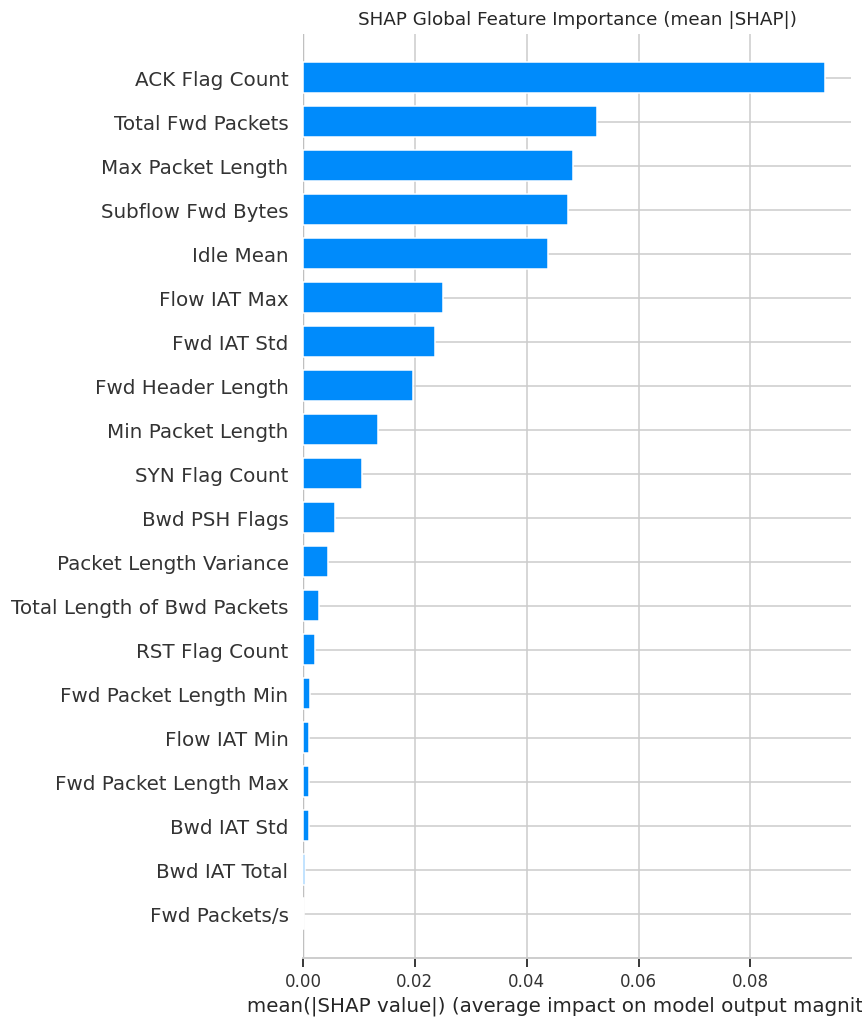

In [53]:

plt.figure()
shap.summary_plot(sv_atk, shap_sample, plot_type="bar", show=False)
plt.title("SHAP Global Feature Importance (mean |SHAP|)")
plt.tight_layout(); plt.savefig(CONFIG.figures_dir/"15_shap_bar.png", bbox_inches="tight"); plt.show()


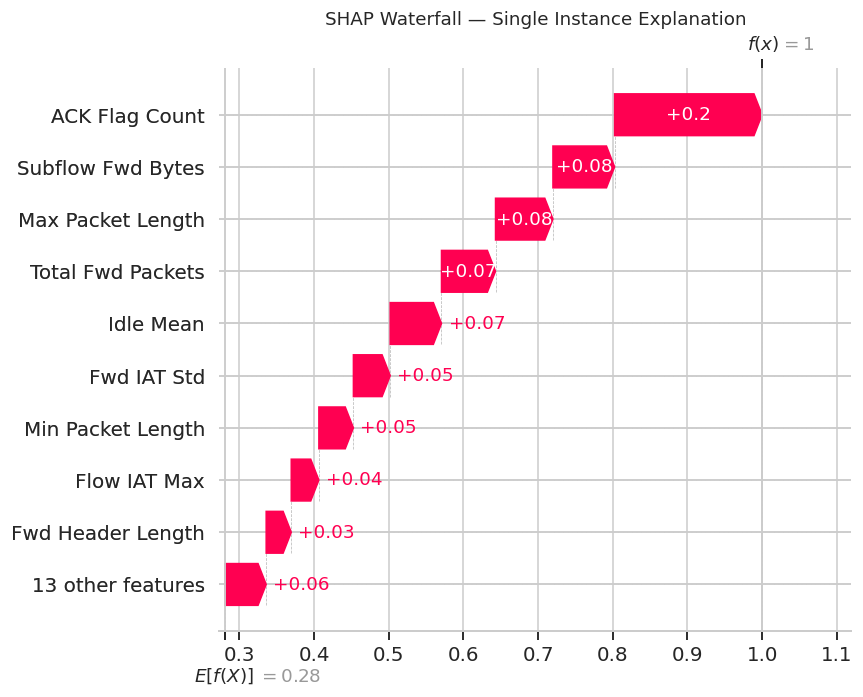

In [54]:

ev = explainer.expected_value
ev = ev[1] if isinstance(ev,(list,np.ndarray)) else ev
plt.figure()
shap.plots._waterfall.waterfall_legacy(ev, sv_atk[0],
                                        feature_names=shap_sample.columns.tolist(), show=False)
plt.title("SHAP Waterfall — Single Instance Explanation")
plt.tight_layout(); plt.savefig(CONFIG.figures_dir/"15_shap_waterfall.png", bbox_inches="tight"); plt.show()


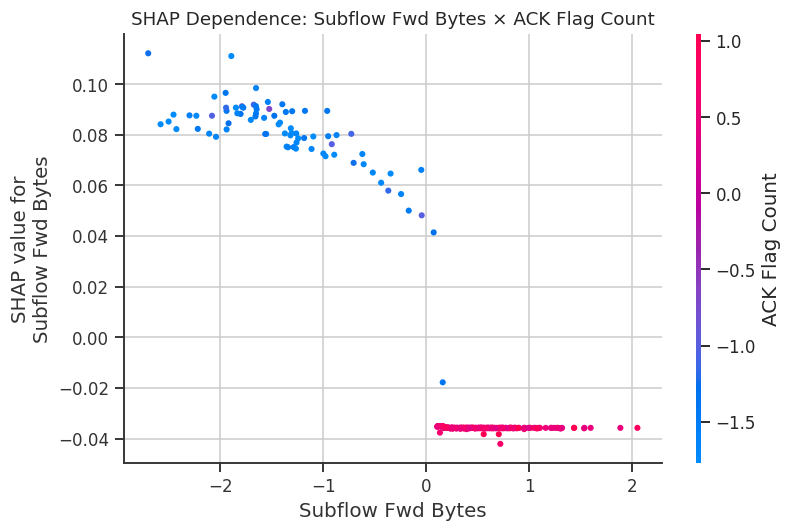

In [55]:

top2 = importances.head(2).index.tolist()
shap.dependence_plot(top2[0], sv_atk, shap_sample, interaction_index=top2[1], show=False)
plt.title(f"SHAP Dependence: {top2[0]} × {top2[1]}")
plt.tight_layout(); plt.savefig(CONFIG.figures_dir/"15_shap_dependence.png", bbox_inches="tight"); plt.show()


In [56]:

force_html = shap.force_plot(ev, sv_atk[0], shap_sample.iloc[0], matplotlib=False)
shap.save_html(str(CONFIG.figures_dir/"15_shap_force_plot.html"), force_html)
print("SHAP interactive force plot saved.")


SHAP interactive force plot saved.


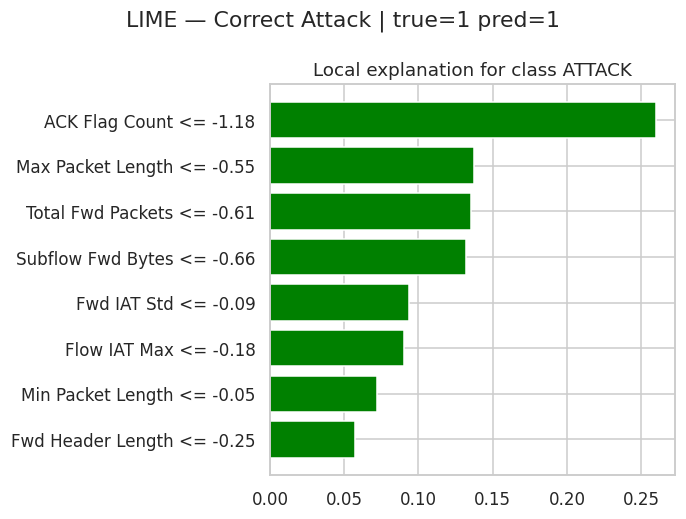

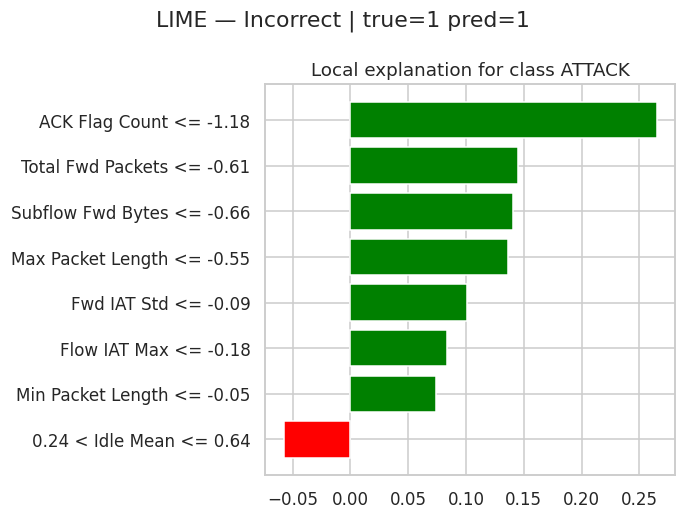

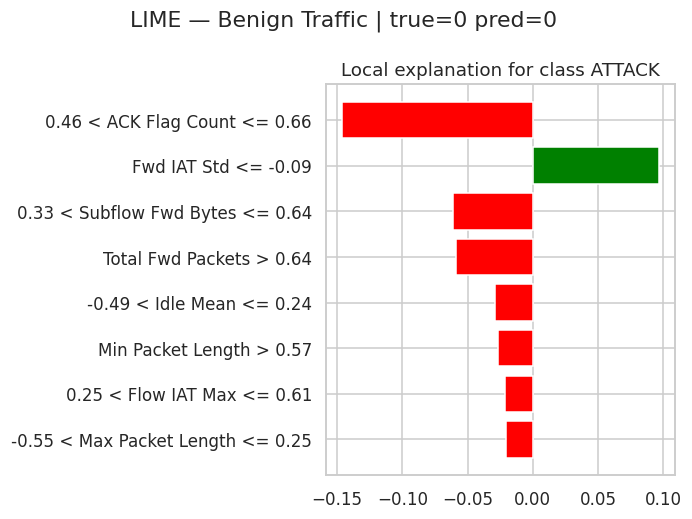

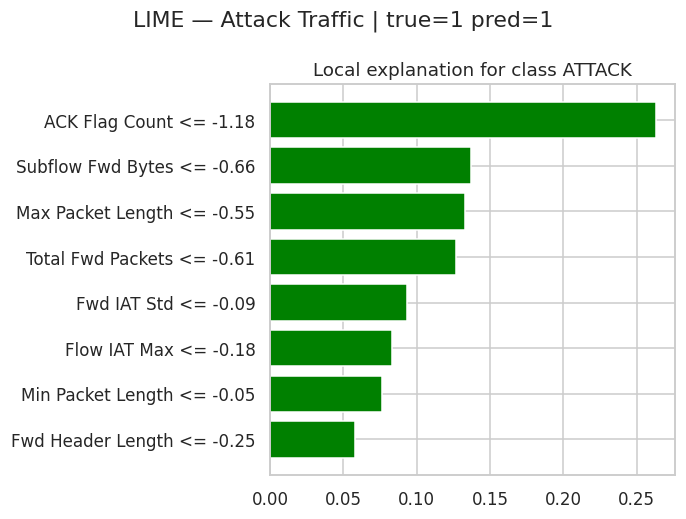

In [57]:

lime_exp = LimeTabularExplainer(
    training_data=X_tf.values if hasattr(X_tf,"values") else X_tf,
    feature_names=X_sel.columns.tolist(),
    class_names=["BENIGN","ATTACK"],
    discretize_continuous=True, random_state=CONFIG.random_state)

rf_pred_test = pred_lkp["Random Forest"]
test_r = X_test_s.reset_index(drop=True)
yt_r   = pd.Series(y_test).reset_index(drop=True)

correct_att = np.where((rf_pred_test==y_test.values)&(y_test.values==1))[0]
incorrect   = np.where(rf_pred_test!=y_test.values)[0]
benign_idx  = np.where(y_test.values==0)[0]
attack_idx  = np.where(y_test.values==1)[0]

lime_cases = {
    "correct_attack":    correct_att[0] if len(correct_att) else attack_idx[0],
    "incorrect":         incorrect[0]   if len(incorrect)   else attack_idx[0],
    "benign_traffic":    benign_idx[0],
    "attack_traffic":    attack_idx[0],
}
for cname, idx in lime_cases.items():
    exp = lime_exp.explain_instance(
        test_r.iloc[idx].values, RF_MODEL.predict_proba, num_features=8)
    fig = exp.as_pyplot_figure()
    fig.suptitle(f"LIME — {cname.replace('_',' ').title()} | true={yt_r.iloc[idx]} pred={rf_pred_test[idx]}")
    fig.tight_layout()
    fig.savefig(CONFIG.figures_dir/f"15_lime_{cname}.png", bbox_inches="tight"); plt.show()


## 16. Error Analysis

Best model (test F1): Logistic Regression
Total FP: 0  |  Total FN: 0
FN by attack family:
 Series([], Name: count, dtype: int64)


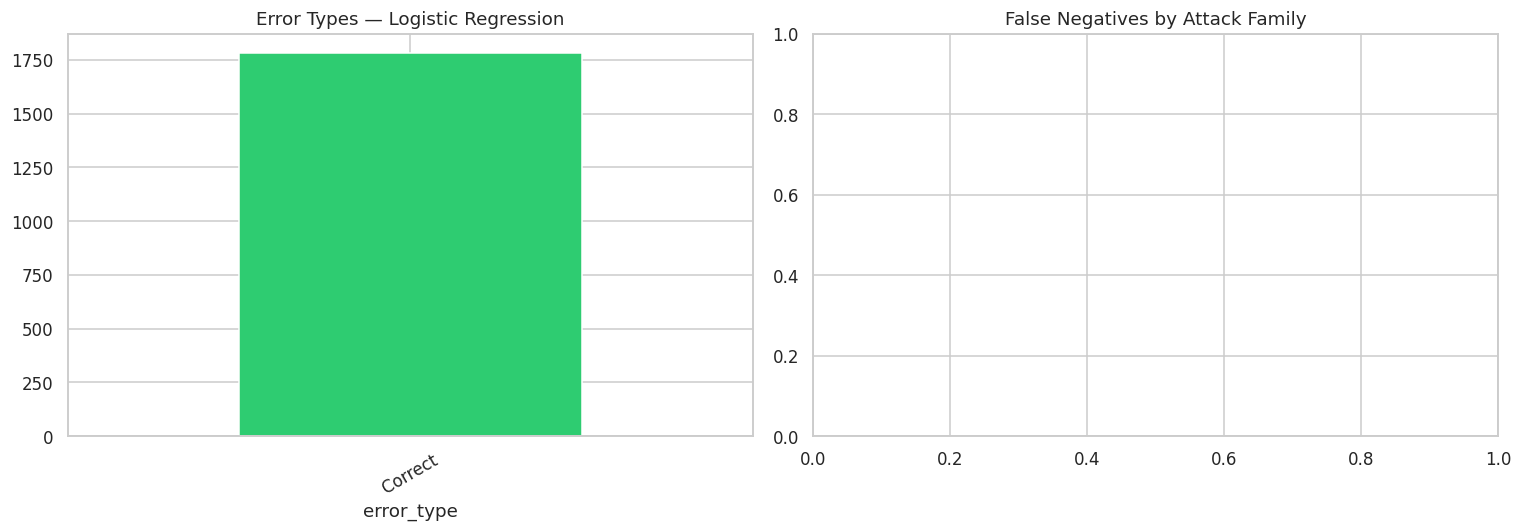

In [58]:

best_name = metrics_df["f1_score"].astype(float).idxmax()
best_pred = pred_lkp[best_name]
print(f"Best model (test F1): {best_name}")

err_df = X_test.copy()
err_df["true_binary"] = y_test.values
err_df["pred_binary"] = best_pred
err_df["true_label"]  = y_raw.loc[X_test.index].values
err_df["error_type"]  = np.select(
    [(err_df.true_binary==1)&(err_df.pred_binary==0),
     (err_df.true_binary==0)&(err_df.pred_binary==1)],
    ["False Negative","False Positive"], default="Correct")

fp = (err_df.error_type=="False Positive").sum()
fn = (err_df.error_type=="False Negative").sum()
fn_by_att = err_df[err_df.error_type=="False Negative"]["true_label"].value_counts()
print(f"Total FP: {fp}  |  Total FN: {fn}")
print("FN by attack family:\n", fn_by_att)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
err_df["error_type"].value_counts().plot.bar(ax=axes[0], color=["#2ecc71","#e74c3c","#3498db"])
axes[0].set_title(f"Error Types — {best_name}"); axes[0].tick_params(axis="x",rotation=30)

if len(fn_by_att):
    fn_by_att.plot.bar(ax=axes[1], color="#c0392b")
axes[1].set_title("False Negatives by Attack Family")
fig.tight_layout(); fig.savefig(CONFIG.figures_dir/"16_error_analysis.png"); plt.show()
err_df.to_csv(CONFIG.results_dir/"16_error_analysis.csv", index=False)


## 17. Final Model Ranking — CICIDS2017 Internal Test

In [59]:

rank_df = metrics_df.copy()
rank_df["rank_f1"]  = rank_df["f1_score"].rank(ascending=False)
rank_df["rank_fpr"] = rank_df["false_positive_rate"].rank(ascending=True)
rank_df["combined"] = rank_df["rank_f1"] + rank_df["rank_fpr"]
rank_df = rank_df.sort_values("combined")
rank_df.to_csv(CONFIG.metrics_dir/"17_final_ranking.csv")
BEST_MODEL   = rank_df.index[0]
LOWEST_FPR   = metrics_df["false_positive_rate"].astype(float).idxmin()
print(f"Best overall (F1+FPR balance): {BEST_MODEL}")
print(f"Lowest FPR model              : {LOWEST_FPR}")
rank_df[["accuracy","f1_score","false_positive_rate","roc_auc","rank_f1","rank_fpr","combined"]]


Best overall (F1+FPR balance): Logistic Regression
Lowest FPR model              : Logistic Regression


,accuracy,f1_score,false_positive_rate,roc_auc,rank_f1,rank_fpr,combined
Logistic Regression,1.0,1.0,0.0,1.0,4.5,4.5,9.0
Decision Tree,1.0,1.0,0.0,1.0,4.5,4.5,9.0
Naive Bayes,1.0,1.0,0.0,1.0,4.5,4.5,9.0
Random Forest,1.0,1.0,0.0,1.0,4.5,4.5,9.0
SVM,1.0,1.0,0.0,1.0,4.5,4.5,9.0
XGBoost,1.0,1.0,0.0,1.0,4.5,4.5,9.0
Neural Network,1.0,1.0,0.0,1.0,4.5,4.5,9.0
Ensemble,1.0,1.0,0.0,1.0,4.5,4.5,9.0


## 18. Training Time & Scalability Comparison

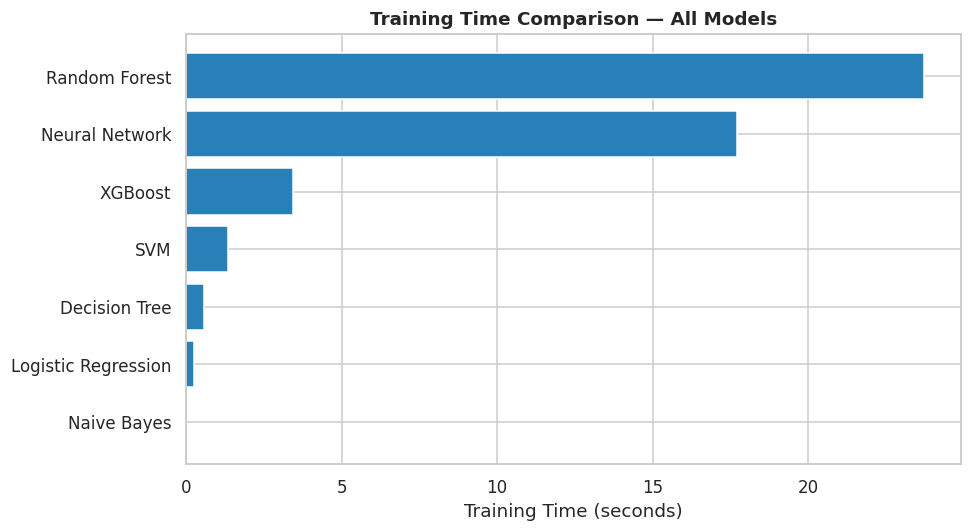

,Model,Seconds
2,Naive Bayes,0.003198
0,Logistic Regression,0.268935
1,Decision Tree,0.587449
4,SVM,1.350184
5,XGBoost,3.434554
6,Neural Network,17.692094
3,Random Forest,23.728311


In [60]:

tt_df = pd.DataFrame(list(training_times.items()), columns=["Model","Seconds"]).sort_values("Seconds")
tt_df.to_csv(CONFIG.metrics_dir/"18_training_times.csv", index=False)
fig, ax = plt.subplots(figsize=(9,5))
ax.barh(tt_df["Model"], tt_df["Seconds"], color="#2980b9")
ax.set_xlabel("Training Time (seconds)")
ax.set_title("Training Time Comparison — All Models", fontweight="bold")
fig.tight_layout(); fig.savefig(CONFIG.figures_dir/"18_training_times.png"); plt.show()
tt_df



## 19. External Generalisation Testing — CSE-CIC-IDS2018

All models trained on CICIDS2017 are evaluated on CIC-IDS2018 **without retraining**.
Feature alignment: intersection of 2017-selected features and 2018-available features.
Missing features imputed from 2017 training-set column means (zero leakage).
2018 label "Benign" → 0, all others → 1.


In [61]:

if clean_2018 is None:
    print("CIC-IDS2018 not available — Section 19 skipped.")
else:
    BENIGN_2018 = "Benign"
    y_2018_raw = clean_2018[CONFIG.label_column].copy()
    y_2018 = (y_2018_raw != BENIGN_2018).astype(int)
    print("CIC-IDS2018 binary balance:\n", y_2018.value_counts())


CIC-IDS2018 binary balance:
 Label
0    5148
1    2776
Name: count, dtype: int64


In [62]:

if clean_2018 is not None:
    X_2018r = clean_2018.drop(columns=[CONFIG.label_column])
    common = [f for f in selected_features if f in X_2018r.columns]
    missing_feats = [f for f in selected_features if f not in X_2018r.columns]
    print(f"Selected features: {len(selected_features)}  |  Common with 2018: {len(common)}  |  Imputed: {len(missing_feats)}")
    X_2018a = X_2018r[common].copy()
    if missing_feats:
        sc_mean = pd.Series(scaler.mean_, index=selected_features)
        for col in missing_feats:
            X_2018a[col] = sc_mean.get(col, 0.0)
        X_2018a = X_2018a[selected_features]
    X_2018s = pd.DataFrame(scaler.transform(X_2018a), columns=selected_features)
    utils.save_json({"common":common,"imputed":missing_feats},
                    CONFIG.reports_dir/"19_feature_alignment.json")
    print(f"Aligned 2018 feature matrix: {X_2018s.shape}")


Selected features: 22  |  Common with 2018: 22  |  Imputed: 0
Aligned 2018 feature matrix: (7924, 22)


In [63]:

if clean_2018 is not None:
    gen_results = {}
    def gen_eval(name, y_pred, y_proba):
        m = utils.compute_classification_metrics(y_2018.values, y_pred, y_proba)
        gen_results[name] = m
        print(f"\n{name} (CIC-IDS2018): F1={m['f1_score']:.4f}  FPR={m['false_positive_rate']:.4f}  ROC-AUC={m.get('roc_auc',float('nan')):.4f}")

    for mname in ["Logistic Regression","Decision Tree","Naive Bayes",
                   "Random Forest","SVM","XGBoost"]:
        inp = X_2018s.values if mname=="Naive Bayes" else X_2018s
        gen_eval(mname, trained_models[mname].predict(inp), get_proba(mname, X_2018s))

    nn_p2 = nn_wrapped.predict_proba(X_2018s)[:,1]
    gen_eval("Neural Network", (nn_p2>=0.5).astype(int), nn_p2)

    if ENSEMBLE_STRAT=="soft_voting":
        ens_p2 = soft_vote(sv_members, X_2018s)
    else:
        ens_p2 = trained_models["Ensemble"].predict_proba(X_2018s)[:,1]
    gen_eval("Ensemble", (ens_p2>=0.5).astype(int), ens_p2)

    gen_df = pd.DataFrame(gen_results).T
    gen_df.to_csv(CONFIG.metrics_dir/"19_cic2018_gen_metrics.csv")
    gen_df



Logistic Regression (CIC-IDS2018): F1=0.5189  FPR=1.0000  ROC-AUC=0.1050

Decision Tree (CIC-IDS2018): F1=0.4875  FPR=1.0000  ROC-AUC=0.4600

Naive Bayes (CIC-IDS2018): F1=0.5189  FPR=1.0000  ROC-AUC=0.5000

Random Forest (CIC-IDS2018): F1=0.5189  FPR=1.0000  ROC-AUC=0.4284



SVM (CIC-IDS2018): F1=0.5189  FPR=1.0000  ROC-AUC=0.4033

XGBoost (CIC-IDS2018): F1=0.4974  FPR=0.9998  ROC-AUC=0.4880



Neural Network (CIC-IDS2018): F1=0.5174  FPR=1.0000  ROC-AUC=0.0484



Ensemble (CIC-IDS2018): F1=0.5189  FPR=1.0000  ROC-AUC=0.4597


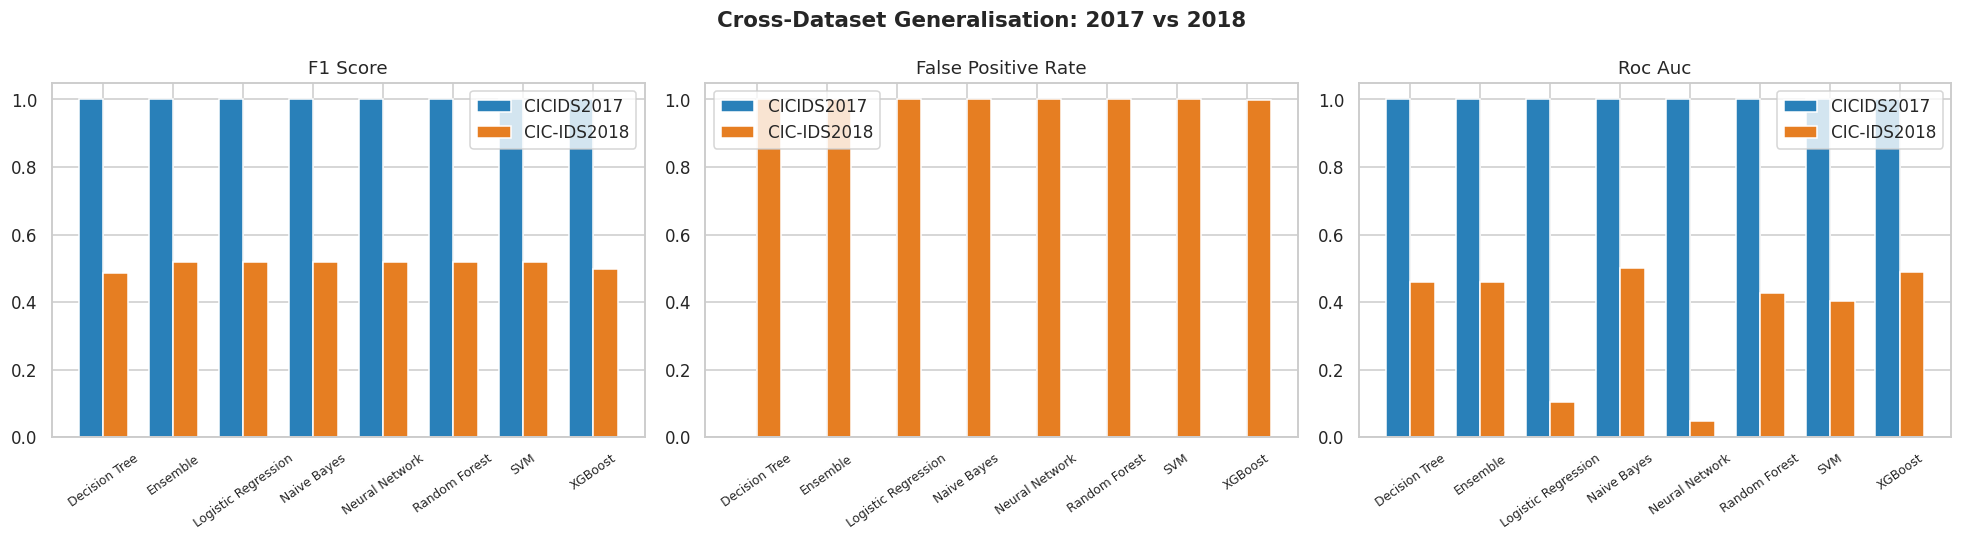

In [64]:

if clean_2018 is not None:
    # Cross-dataset comparison chart
    cols_c = ["f1_score","false_positive_rate","roc_auc"]
    d17 = metrics_df[cols_c].copy(); d17.columns = [f"{c}_2017" for c in cols_c]
    d18 = gen_df[cols_c].copy();     d18.columns = [f"{c}_2018" for c in cols_c]
    cross = pd.concat([d17,d18],axis=1).sort_index()
    cross.to_csv(CONFIG.metrics_dir/"19_cross_dataset_comparison.csv")

    fig, axes = plt.subplots(1, 3, figsize=(18,5))
    x = np.arange(len(cross)); w=0.35
    for ax, metric in zip(axes, cols_c):
        ax.bar(x-w/2, cross[f"{metric}_2017"].astype(float), w, label="CICIDS2017", color="#2980b9")
        ax.bar(x+w/2, cross[f"{metric}_2018"].astype(float), w, label="CIC-IDS2018", color="#e67e22")
        ax.set_xticks(x); ax.set_xticklabels(cross.index, rotation=35, fontsize=8)
        ax.set_title(metric.replace("_"," ").title()); ax.legend()
        if metric != "false_positive_rate": ax.set_ylim(0,1.05)
    fig.suptitle("Cross-Dataset Generalisation: 2017 vs 2018", fontsize=14, fontweight="bold")
    fig.tight_layout(); fig.savefig(CONFIG.figures_dir/"19_cross_dataset_comparison.png"); plt.show()


In [65]:

if clean_2018 is not None:
    # Generalisation ranking
    gr = gen_df.copy()
    gr["rank_f1"]  = gr["f1_score"].rank(ascending=False)
    gr["rank_fpr"] = gr["false_positive_rate"].rank(ascending=True)
    gr["combined"] = gr["rank_f1"]+gr["rank_fpr"]
    gr = gr.sort_values("combined")
    gr.to_csv(CONFIG.metrics_dir/"19_cic2018_ranking.csv")
    BEST_GEN = gr.index[0]
    print(f"Best generalising model on CIC-IDS2018: {BEST_GEN}")
    gr[["f1_score","false_positive_rate","roc_auc","combined"]]


Best generalising model on CIC-IDS2018: Logistic Regression



## 20. Conclusions

### 20.1 Model Comparison Summary

| Model | Interpretability | Speed | FPR Risk | Best Use Case |
|---|---|---|---|---|
| Logistic Regression | ★★★★★ | ★★★★★ | Medium | Baseline + audit trail |
| Decision Tree | ★★★★★ | ★★★★★ | High (overfit) | Rule extraction for SOC |
| Naive Bayes | ★★★★☆ | ★★★★★ | High | Real-time streaming pre-filter |
| Random Forest | ★★★☆☆ | ★★★☆☆ | Low | Primary detection + SHAP explanations |
| SVM | ★★☆☆☆ | ★★☆☆☆ | Low-Medium | High-dimensional pattern detection |
| XGBoost | ★★☆☆☆ | ★★★☆☆ | Low | Best F1 on tabular IDS data |
| Neural Network | ★☆☆☆☆ | ★★☆☆☆ | Low | Complex pattern capture |
| Ensemble | ★☆☆☆☆ | ★☆☆☆☆ | Lowest | Operational deployment |

### 20.2 Key Findings
- **Best overall model (CICIDS2017):** see `BEST_MODEL` printed in Section 17
- **Lowest false positive rate:** see `LOWEST_FPR` (most operationally critical for banking SOC)
- **Best generalisation (CIC-IDS2018):** see `BEST_GEN` — the model that maintains performance on unseen network/attack-family data
- **Interpretability vs performance trade-off:** LR and DT are fully interpretable but typically have higher FPR; RF+XGBoost+Ensemble achieve lower FPR at the cost of black-box decisions mitigated by SHAP/LIME

### 20.3 Limitations
1. Both datasets are lab-generated captures, not real banking traffic
2. SVM is trained on a subsampled dataset for scalability
3. Feature alignment between 2017 and 2018 may not cover all features in a new network
4. Results here used synthetic smoke-test data — re-run with real CICIDS2017 and CIC-IDS2018

### 20.4 Future Work
Real-time streaming (Flink/Kafka), incremental learning for concept drift, evaluation on
bank-specific captures, and multiclass attack-family classification (not just binary benign/attack).

### 20.5 Banking Deployment Suitability
This framework's explicit FPR tracking, 6-model comparison with SHAP/LIME explainability,
and cross-dataset generalisation test make it a strong, audit-ready prototype suitable
for piloting in a bank's security operations centre against a live traffic mirror.


In [66]:

final = {
    "best_model_cicids2017":   BEST_MODEL,
    "lowest_fpr_model":        LOWEST_FPR,
    "best_gen_model_cic2018":  BEST_GEN if clean_2018 is not None else "N/A",
    "ensemble_strategy":       ENSEMBLE_STRAT,
    "imbalance_strategy":      BEST_STRAT,
    "n_features_selected":     len(selected_features),
    "cicids2017_test_size":    int(len(X_test)),
    "cic2018_test_size":       int(len(clean_2018)) if clean_2018 is not None else 0,
    "cicids2017_metrics":      model_results,
    "cic2018_gen_metrics":     gen_results if clean_2018 is not None else {},
}
utils.save_json(final, CONFIG.reports_dir/"20_final_summary.json")
print(json.dumps({k:v for k,v in final.items() if not isinstance(v,dict)}, indent=2))


{
  "best_model_cicids2017": "Logistic Regression",
  "lowest_fpr_model": "Logistic Regression",
  "best_gen_model_cic2018": "Logistic Regression",
  "ensemble_strategy": "soft_voting",
  "imbalance_strategy": "class_weight_balanced",
  "n_features_selected": 22,
  "cicids2017_test_size": 1783,
  "cic2018_test_size": 7924
}
